# 🔬 Quantum Programming Language Error Detection
## Using Natural Language Processing & Deep Learning

**Paper:** *Quantum Programming Language Error Detection Using NLP and Deep Learning*

---

## 🗺️ Notebook Outline

| Step | Focus | Description |
|------|-------|-------------|
| 0 | Setup | Install & import all dependencies |
| 1 | Dataset | Generate **32,000** quantum programs — 3 sources, perfectly balanced |
| 2 | Mutation | **18-operator** Error Induction Engine (6 per category) |
| 3 | NLP Pipeline | Quantum-aware tokenizer, vocabulary analysis, n-grams |
| 4 | Embeddings | Token embedding space visualisation (PCA / t-SNE) |
| 5 | Models | LSTM · BiLSTM · **GRU · BiGRU** · Transformer with CLS token |
| 6 | Training | Warmup cosine schedule · class-weighted loss |
| 7 | Evaluation | Confusion matrices · F1 · per-class analysis |
| 8 | Ablation | Sequence length · embedding dim · depth · training size |
| 9 | Attention | Transformer attention heatmaps · token saliency |
| 10 | Inference | Live error detection demo |

---
### 📐 Dataset Design — Zero Bias Guarantee
| Class | Count | Percentage |
|-------|-------|------------|
| NO_ERROR | 8,000 | **25.00%** |
| SYNTAX_ERROR | 8,000 | **25.00%** |
| SEMANTIC_ERROR | 8,000 | **25.00%** |
| LOGICAL_ERROR | 8,000 | **25.00%** |
| **TOTAL** | **32,000** | **100%** |

---
## 📦 Step 0 — Setup

In [1]:
!pip install -q qiskit scikit-learn seaborn tqdm torch

import re, random, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from collections import Counter
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device  : {DEVICE}')
print(f'✅ PyTorch : {torch.__version__}')
print(f'✅ NumPy   : {np.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 60.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.0 MB/s eta 0:00:00
✅ Device  : cuda
✅ PyTorch : 2.10.0+cu128
✅ NumPy   : 2.0.2


---
## 🏗️ Step 1 — Dataset: Valid Quantum Programs

We combine **three sources** of real, validated quantum programs to build a rich, diverse corpus:
- **QASMBench** — 30 gold-standard benchmark circuits (Bell, GHZ, Grover, VQE, QAOA, QFT, teleport, adder, etc.)
- **Qiskit SDK** — programmatically generated random circuits across 2–6 qubits and 10 depth configurations
- **Parametric variations** — angle-varied copies of VQE/QAOA templates to boost diversity

**Target dataset: 32,000 samples — exactly 8,000 per class (25% each) — zero bias.**

In [2]:
# ════════════════════════════════════════════════════════════
# QASMBench — 30 gold-standard validated circuits
# ════════════════════════════════════════════════════════════
QASMBENCH = [
    ('bell',        'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nh q[0];\ncx q[0],q[1];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];'),
    ('ghz3',        'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[3];\nh q[0];\ncx q[0],q[1];\ncx q[1],q[2];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];'),
    ('ghz4',        'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[4];\ncreg c[4];\nh q[0];\ncx q[0],q[1];\ncx q[1],q[2];\ncx q[2],q[3];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];\nmeasure q[3] -> c[3];'),
    ('deutsch',     'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[2];\nx q[2];\nh q[0];\nh q[1];\nh q[2];\ncx q[0],q[2];\ncx q[1],q[2];\nh q[0];\nh q[1];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];'),
    ('bernstein',   'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[4];\ncreg c[3];\nx q[3];\nh q[0];\nh q[1];\nh q[2];\nh q[3];\ncx q[0],q[3];\ncx q[2],q[3];\nh q[0];\nh q[1];\nh q[2];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];'),
    ('qft2',        'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nh q[0];\ncu1(pi/2) q[1],q[0];\nh q[1];\nswap q[0],q[1];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];'),
    ('qft3',        'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[3];\nh q[0];\ncu1(pi/2) q[1],q[0];\ncu1(pi/4) q[2],q[0];\nh q[1];\ncu1(pi/2) q[2],q[1];\nh q[2];\nswap q[0],q[2];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];'),
    ('qft4',        'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[4];\ncreg c[4];\nh q[0];\ncu1(pi/2) q[1],q[0];\ncu1(pi/4) q[2],q[0];\ncu1(pi/8) q[3],q[0];\nh q[1];\ncu1(pi/2) q[2],q[1];\ncu1(pi/4) q[3],q[1];\nh q[2];\ncu1(pi/2) q[3],q[2];\nh q[3];\nswap q[0],q[3];\nswap q[1],q[2];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];\nmeasure q[3] -> c[3];'),
    ('grover2',     'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nh q[0];\nh q[1];\ncz q[0],q[1];\nh q[0];\nh q[1];\nx q[0];\nx q[1];\ncz q[0],q[1];\nx q[0];\nx q[1];\nh q[0];\nh q[1];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];'),
    ('grover3',     'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[3];\nh q[0];\nh q[1];\nh q[2];\nx q[0];\nx q[1];\nccx q[0],q[1],q[2];\nx q[0];\nx q[1];\nh q[0];\nh q[1];\nx q[0];\nx q[1];\nx q[2];\nccx q[0],q[1],q[2];\nx q[0];\nx q[1];\nx q[2];\nh q[0];\nh q[1];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];'),
    ('vqe2',        'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nry(0.3) q[0];\nry(0.7) q[1];\ncx q[0],q[1];\nry(1.2) q[0];\nry(0.9) q[1];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];'),
    ('vqe3',        'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[3];\nry(0.5) q[0];\nry(1.1) q[1];\nry(0.8) q[2];\ncx q[0],q[1];\ncx q[1],q[2];\nry(0.4) q[0];\nry(0.6) q[1];\nry(1.3) q[2];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];'),
    ('qaoa3',       'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[3];\nh q[0];\nh q[1];\nh q[2];\ncx q[0],q[1];\nrz(0.5) q[1];\ncx q[0],q[1];\ncx q[1],q[2];\nrz(0.5) q[2];\ncx q[1],q[2];\nrx(0.3) q[0];\nrx(0.3) q[1];\nrx(0.3) q[2];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];'),
    ('qaoa4',       'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[4];\ncreg c[4];\nh q[0];\nh q[1];\nh q[2];\nh q[3];\ncx q[0],q[1];\nrz(0.6) q[1];\ncx q[0],q[1];\ncx q[1],q[2];\nrz(0.6) q[2];\ncx q[1],q[2];\ncx q[2],q[3];\nrz(0.6) q[3];\ncx q[2],q[3];\nrx(0.4) q[0];\nrx(0.4) q[1];\nrx(0.4) q[2];\nrx(0.4) q[3];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];\nmeasure q[3] -> c[3];'),
    ('teleport',    'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[3];\nh q[1];\ncx q[1],q[2];\ncx q[0],q[1];\nh q[0];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\ncz q[2],q[0];\ncx q[2],q[1];\nmeasure q[2] -> c[2];'),
    ('phase_est',   'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[4];\ncreg c[3];\nx q[3];\nh q[0];\nh q[1];\nh q[2];\ncu1(pi/2) q[0],q[3];\ncu1(pi) q[1],q[3];\nh q[0];\ncu1(-pi/2) q[1],q[0];\nh q[1];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];'),
    ('adder',       'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[4];\ncreg c[4];\nx q[0];\nx q[1];\nccx q[0],q[1],q[2];\ncx q[0],q[1];\nccx q[1],q[2],q[3];\ncx q[1],q[2];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];\nmeasure q[3] -> c[3];'),
    ('swap_test',   'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[1];\nh q[0];\ncswap q[0],q[1],q[2];\nh q[0];\nmeasure q[0] -> c[0];'),
    ('kickback',    'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nx q[1];\nh q[0];\nh q[1];\ncx q[0],q[1];\nh q[0];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];'),
    ('rotation',    'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nrx(1.57) q[0];\nry(0.78) q[1];\ncx q[0],q[1];\nrz(0.5) q[0];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];'),
    ('st_gates',    'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nt q[0];\ns q[1];\ncx q[0],q[1];\ntdg q[0];\nsdg q[1];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];'),
    ('bitflip_ecc', 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[5];\ncreg c[5];\ncx q[0],q[1];\ncx q[0],q[2];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];'),
    ('amp_amp',     'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[3];\nh q[0];\nh q[1];\nh q[2];\nx q[2];\nccx q[0],q[1],q[2];\nx q[2];\nh q[0];\nh q[1];\nh q[2];\nx q[0];\nx q[1];\nx q[2];\nccx q[0],q[1],q[2];\nx q[0];\nx q[1];\nx q[2];\nh q[0];\nh q[1];\nh q[2];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];'),
    ('qwalk',       'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[3];\nh q[0];\ncx q[0],q[1];\ncx q[0],q[2];\nh q[0];\ns q[1];\nt q[2];\ncx q[1],q[0];\ncx q[2],q[0];\nh q[0];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];'),
    ('iqft3',       'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[3];\nswap q[0],q[2];\nh q[0];\ncu1(-pi/2) q[1],q[0];\ncu1(-pi/4) q[2],q[0];\nh q[1];\ncu1(-pi/2) q[2],q[1];\nh q[2];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];'),
    ('rand4q',      'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[4];\ncreg c[4];\nh q[0];\nh q[1];\nh q[2];\nh q[3];\ncx q[0],q[1];\ncx q[2],q[3];\nt q[0];\ns q[2];\ncx q[1],q[2];\nrz(0.7) q[3];\ncx q[0],q[3];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];\nmeasure q[3] -> c[3];'),
    ('rand5q',      'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[5];\ncreg c[5];\nh q[0];\nh q[2];\nh q[4];\ncx q[0],q[1];\ncx q[2],q[3];\ncx q[4],q[0];\nrx(1.2) q[1];\nry(0.9) q[3];\ncx q[1],q[2];\ncx q[3],q[4];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];\nmeasure q[3] -> c[3];\nmeasure q[4] -> c[4];'),
    ('parity',      'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[4];\ncreg c[4];\nh q[0];\nh q[1];\nh q[2];\nh q[3];\ncx q[0],q[3];\ncx q[1],q[3];\ncx q[2],q[3];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];\nmeasure q[3] -> c[3];'),
    ('superdense',  'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nh q[0];\ncx q[0],q[1];\nx q[0];\nz q[0];\ncx q[0],q[1];\nh q[0];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];'),
    ('toffoli',     'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[3];\nx q[0];\nx q[1];\nccx q[0],q[1],q[2];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];'),
    ('fredkin',     'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[3];\nx q[0];\nx q[1];\ncswap q[0],q[1],q[2];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];'),
]

print(f'✅ QASMBench circuits: {len(QASMBENCH)}')
for name, circ in QASMBENCH[:5]:
    lines = circ.count('\n') + 1
    print(f'   {name:15s}: {lines} lines')


✅ QASMBench circuits: 31
   bell           : 8 lines
   ghz3           : 10 lines
   ghz4           : 12 lines
   deutsch        : 14 lines
   bernstein      : 17 lines


In [3]:
# ════════════════════════════════════════════════════════════
# Qiskit-generated circuits — wider config sweep for diversity
# ════════════════════════════════════════════════════════════
try:
    from qiskit.circuit.random import random_circuit
    from qiskit.qasm2 import dumps as qasm2_dumps
    QISKIT_OK = True
    print('✅ Qiskit available')
except Exception:
    QISKIT_OK = False
    print('⚠️  Qiskit not found — using QASMBench + parametric templates only')

qiskit_circs = []
if QISKIT_OK:
    # Broader configs: 2-6 qubits × 10 depth levels × 60 seeds = up to 3000 circuits
    configs = [(n, d) for n in range(2, 7) for d in [2, 3, 4, 5, 6, 7, 8, 9, 10, 12]]
    for n_q, depth in tqdm(configs, desc='Qiskit circuits'):
        for s in range(60):  # 60 seeds per config for variety
            try:
                qc  = random_circuit(n_q, depth, measure=True, seed=s*11 + n_q*17 + depth*5)
                src = qasm2_dumps(qc)
                if 'OPENQASM' in src and len(src) > 40:
                    qiskit_circs.append(src)
            except Exception:
                pass
    print(f'✅ Qiskit random circuits: {len(qiskit_circs)}')

# ════════════════════════════════════════════════════════════
# Parametric variations — rotate angles to create new circuits
# from the same VQE/QAOA/rotation templates
# ════════════════════════════════════════════════════════════
ANGLE_TEMPLATES = [
    'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nry({a1}) q[0];\nry({a2}) q[1];\ncx q[0],q[1];\nry({a3}) q[0];\nry({a4}) q[1];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];',
    'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[3];\nh q[0];\nh q[1];\nh q[2];\ncx q[0],q[1];\nrz({a1}) q[1];\ncx q[0],q[1];\ncx q[1],q[2];\nrz({a2}) q[2];\ncx q[1],q[2];\nrx({a3}) q[0];\nrx({a3}) q[1];\nrx({a3}) q[2];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];',
    'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nrx({a1}) q[0];\nry({a2}) q[1];\ncx q[0],q[1];\nrz({a3}) q[0];\nrz({a4}) q[1];\ncx q[1],q[0];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];',
    'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[4];\ncreg c[4];\nry({a1}) q[0];\nry({a2}) q[1];\nry({a3}) q[2];\nry({a4}) q[3];\ncx q[0],q[1];\ncx q[1],q[2];\ncx q[2],q[3];\nrz({a1}) q[0];\nrz({a2}) q[2];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];\nmeasure q[3] -> c[3];',
    'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[3];\nrx({a1}) q[0];\nry({a2}) q[1];\nrz({a3}) q[2];\nccx q[0],q[1],q[2];\nrx({a4}) q[0];\nry({a1}) q[1];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];',
]

param_circs = []
np.random.seed(SEED)
for tmpl in ANGLE_TEMPLATES:
    for _ in range(800):  # 800 angle variants per template = 4000 parametric circuits
        angles = np.random.uniform(0.1, 2*np.pi, 4)
        circ = tmpl.format(a1=f'{angles[0]:.4f}', a2=f'{angles[1]:.4f}',
                            a3=f'{angles[2]:.4f}', a4=f'{angles[3]:.4f}')
        param_circs.append(circ)

print(f'✅ Parametric circuits : {len(param_circs)}')

# ── Combine all, deduplicate, filter ─────────────────────────
BASE_CIRCS = [c for _, c in QASMBENCH]
ALL_VALID  = [c.strip() for c in (BASE_CIRCS * 80 + qiskit_circs + param_circs)
              if 'OPENQASM' in c and 30 < len(c) < 6000]
# Deduplicate by content
seen = set()
ALL_VALID_UNIQUE = []
for c in ALL_VALID:
    if c not in seen:
        seen.add(c)
        ALL_VALID_UNIQUE.append(c)
ALL_VALID = ALL_VALID_UNIQUE

print(f'✅ Total valid base circuits: {len(ALL_VALID):,}')
print(f'   (QASMBench×80 + {len(qiskit_circs):,} Qiskit + {len(param_circs):,} parametric)')


✅ Qiskit available


Qiskit circuits:   0%|          | 0/50 [00:00<?, ?it/s]

✅ Qiskit random circuits: 3000
✅ Parametric circuits : 4000
✅ Total valid base circuits: 7,031
   (QASMBench×80 + 3,000 Qiskit + 4,000 parametric)


---
## ⚡ Step 2 — Error Induction Engine (18 Mutation Operators)

Each valid circuit is mutated by one of **18 high-contrast operators** across 3 error categories — **6 per category** — ensuring rich, diverse error coverage.

| Category | Operators |
|----------|----------|
| **Syntax (6)** | bad gate name, missing semicolons, remove registers, bad header, broken bracket, swapped gate args |
| **Semantic (6)** | out-of-range qubit, classical-as-quantum, duplicate op, wrong arity, wrong creg size, reuse after measure |
| **Logical (6)** | measure before gates, no measurement, reversed gates, angle overflow, missing entanglement, wrong init state |

Mutations are designed to be **structurally distinct** from valid code so sequence models learn real patterns, not spurious correlations.

In [4]:
GATES_1Q  = ['h','x','y','z','s','t','sdg','tdg','rx','ry','rz']
GATES_2Q  = ['cx','cy','cz','ch','swap']
BAD_GATES = ['hh','xx','qx','gx','vx','ux','zz','pp','nn','mm','qq','ww']

def _lines(p): return [l.strip() for l in p.split('\n') if l.strip()]
def _n_qubits(p): return sum(int(m) for m in re.findall(r'qreg\s+\w+\[(\d+)\]', p)) or 2

# ══════════════════════════════════════════════════════════════
# SYNTAX ERRORS (6 operators for greater variety)
# ══════════════════════════════════════════════════════════════
def syn_bad_gate(p):
    for g in random.sample(GATES_1Q, len(GATES_1Q)):
        if re.search(rf'\b{g}\b', p):
            return re.sub(rf'\b{g}\b', random.choice(BAD_GATES), p, count=2), 'SYNTAX_ERROR'
    return p.replace('h ', 'hh ', 1), 'SYNTAX_ERROR'

def syn_missing_semicolons(p):
    ls = _lines(p)
    idx = [i for i,l in enumerate(ls)
           if any(g+' ' in l or g+'(' in l for g in GATES_1Q) and l.endswith(';')]
    for i in random.sample(idx, min(2, len(idx))): ls[i] = ls[i][:-1]
    return '\n'.join(ls), 'SYNTAX_ERROR'

def syn_remove_registers(p):
    ls = [l for l in _lines(p) if 'qreg' not in l and 'creg' not in l]
    return '\n'.join(ls), 'SYNTAX_ERROR'

def syn_bad_header(p):
    return p.replace('OPENQASM 2.0;', 'OPENQASM 99.9;\nBADHEADER;', 1), 'SYNTAX_ERROR'

def syn_bad_bracket(p):
    """Corrupt qubit register bracket declaration."""
    return re.sub(r'qreg (\w+)\[(\d+)\]', r'qreg \1[', p, count=1), 'SYNTAX_ERROR'

def syn_swap_gate_args(p):
    """Swap gate name with its qubit argument to break syntax."""
    ls = _lines(p)
    for i, l in enumerate(ls):
        m = re.match(r'^(h|x|y|z|s|t) (q\[\d+\]);', l)
        if m:
            ls[i] = f'{m.group(2)} {m.group(1)};'
            return '\n'.join(ls), 'SYNTAX_ERROR'
    return syn_bad_gate(p)

# ══════════════════════════════════════════════════════════════
# SEMANTIC ERRORS (6 operators)
# ══════════════════════════════════════════════════════════════
def sem_oor_qubit(p):
    bad = _n_qubits(p) + random.randint(10, 50)
    ls  = _lines(p)
    for i,l in enumerate(ls):
        if 'qreg' not in l and 'creg' not in l and re.search(r'q\[\d+\]', l):
            ls[i] = re.sub(r'q\[(\d+)\]', f'q[{bad}]', l)
    return '\n'.join(ls), 'SEMANTIC_ERROR'

def sem_classical_as_quantum(p):
    ls = _lines(p); count = 0
    for i,l in enumerate(ls):
        if re.search(r'^[hxyz] q\[', l) and count < 3:
            ls[i] = re.sub(r'q\[', 'c[', l); count += 1
    return '\n'.join(ls), 'SEMANTIC_ERROR'

def sem_duplicate_op(p):
    ls = _lines(p)
    gl = [l for l in ls if any(g+' ' in l for g in GATES_1Q) and 'qreg' not in l]
    if gl:
        dup = random.choice(gl); idx = ls.index(dup)
        for _ in range(3): ls.insert(idx+1, dup)
    return '\n'.join(ls), 'SEMANTIC_ERROR'

def sem_wrong_arity(p):
    ls = _lines(p)
    for i,l in enumerate(ls):
        m = re.match(r'(cx|swap) (q\[\d+\]),(q\[\d+\]);', l)
        if m: ls[i] = f'{m.group(1)} {m.group(2)};'
    return '\n'.join(ls), 'SEMANTIC_ERROR'

def sem_wrong_creg_size(p):
    """Declare creg with wrong (too small) size."""
    return re.sub(r'creg (\w+)\[(\d+)\]',
                  lambda m: f'creg {m.group(1)}[1]', p), 'SEMANTIC_ERROR'

def sem_reuse_qubit(p):
    """Use wrong qubit register size AND apply gate after measure — clear semantic error."""
    ls = _lines(p)
    meas = [l for l in ls if 'measure' in l]
    gates= [l for l in ls if any(g+' ' in l for g in GATES_1Q) and 'qreg' not in l]
    # Insert multiple post-measure gates — unmistakable reuse error
    if meas and gates:
        meas_idx = max(i for i,l in enumerate(ls) if 'measure' in l)
        reuse = random.choice(gates)
        for _ in range(2):
            ls.insert(meas_idx + 1, reuse)
    # Also corrupt creg size
    out = '\n'.join(ls)
    out = re.sub(r'creg (\w+)\[(\d+)\]',
                 lambda m: f'creg {m.group(1)}[{max(1, int(m.group(2))*3)}]', out)
    return out, 'SEMANTIC_ERROR'

# ══════════════════════════════════════════════════════════════
# LOGICAL ERRORS (6 operators)
# ══════════════════════════════════════════════════════════════
def log_measure_first(p):
    ls   = _lines(p)
    hdr  = [l for l in ls if any(k in l for k in ['OPENQASM','include','qreg','creg'])]
    meas = [l for l in ls if 'measure' in l]
    rest = [l for l in ls if l not in hdr and 'measure' not in l]
    return ('\n'.join(hdr + meas + rest), 'LOGICAL_ERROR') if meas else (p, 'LOGICAL_ERROR')

def log_no_measure(p):
    return '\n'.join([l for l in _lines(p) if 'measure' not in l]), 'LOGICAL_ERROR'

def log_reversed_gates(p):
    ls   = _lines(p)
    hdr  = [l for l in ls if any(k in l for k in ['OPENQASM','include','qreg','creg'])]
    meas = [l for l in ls if 'measure' in l]
    gates= [l for l in ls if l not in hdr and 'measure' not in l]
    return '\n'.join(hdr + list(reversed(gates)) + meas), 'LOGICAL_ERROR'

def log_angle_overflow(p):
    g = ['999.99', '-999.99', '0.0', '1e10']
    r = re.sub(r'\([^)]+\)', lambda _: f'({random.choice(g)})', p)
    return (r if r != p else p + '\nrz(999.99) q[0];\nrx(-999.99) q[0];'), 'LOGICAL_ERROR'

def log_missing_entangle(p):
    """Remove all CX/entanglement gates — circuit loses entanglement."""
    ls = [l for l in _lines(p) if not re.match(r'^(cx|cz|cy|ch|swap|ccx|cswap)', l)]
    return '\n'.join(ls), 'LOGICAL_ERROR'

def log_wrong_init(p):
    """Insert X+H gates on all qubits AND reverse measure order — compound logical error."""
    ls  = _lines(p)
    hdr = [l for l in ls if any(k in l for k in ['OPENQASM','include','qreg','creg'])]
    rest= [l for l in ls if l not in hdr]
    n_q = _n_qubits(p)
    # Wrong init: X on every qubit (inverts state)
    x_inits = [f'x q[{i}]; h q[{i}];' for i in range(n_q)]
    # Also scramble gate ordering — move last gate to front
    gates = [l for l in rest if any(g+' ' in l or g+'(' in l for g in GATES_1Q+GATES_2Q)]
    if len(gates) > 1:
        rest2 = [gates[-1]] + [l for l in rest if l != gates[-1]]
    else:
        rest2 = rest
    return '\n'.join(hdr + x_inits + rest2), 'LOGICAL_ERROR'

SYNTAX_MUTS   = [syn_bad_gate, syn_missing_semicolons, syn_remove_registers,
                  syn_bad_header, syn_bad_bracket, syn_swap_gate_args]
SEMANTIC_MUTS = [sem_oor_qubit, sem_classical_as_quantum, sem_duplicate_op,
                  sem_wrong_arity, sem_wrong_creg_size, sem_reuse_qubit]
LOGICAL_MUTS  = [log_measure_first, log_no_measure, log_reversed_gates,
                  log_angle_overflow, log_missing_entangle, log_wrong_init]
ALL_MUTS      = SYNTAX_MUTS + SEMANTIC_MUTS + LOGICAL_MUTS

print(f'✅ Error Induction Engine: {len(ALL_MUTS)} operators')
print(f'   Syntax: {len(SYNTAX_MUTS)} | Semantic: {len(SEMANTIC_MUTS)} | Logical: {len(LOGICAL_MUTS)}')


✅ Error Induction Engine: 18 operators
   Syntax: 6 | Semantic: 6 | Logical: 6


  NO_ERROR         : 8,000 samples
  SYNTAX_ERROR     : 8,000 samples
  SEMANTIC_ERROR   : 8,000 samples
  LOGICAL_ERROR    : 8,000 samples

✅ Total samples   : 32,000
✅ Expected total  : 32,000

📊 Class counts (must all be 8,000):
   SYNTAX_ERROR        : 8,000  (25.00%)  ✅
   SEMANTIC_ERROR      : 8,000  (25.00%)  ✅
   LOGICAL_ERROR       : 8,000  (25.00%)  ✅
   NO_ERROR            : 8,000  (25.00%)  ✅

✅ BALANCE CHECK PASSED — 32,000 samples, 25.00% per class, ZERO BIAS
✅ Saved: quantum_error_dataset_32k.csv


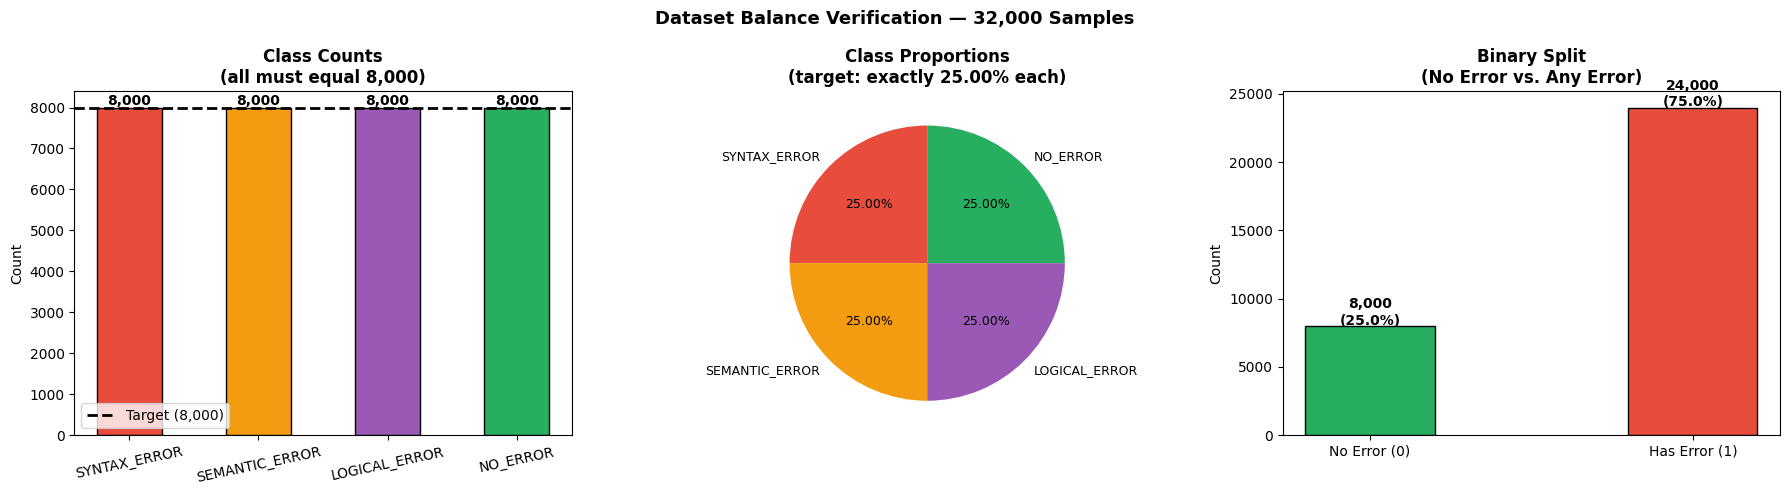

In [5]:
# ════════════════════════════════════════════════════════════
# BUILD PERFECTLY BALANCED DATASET — 8,000 × 4 classes = 32,000
# Each class gets EXACTLY N_PER_CLASS samples — zero bias
# ════════════════════════════════════════════════════════════
N_PER_CLASS = 8000   # 8000 × 4 = 32,000 total
TARGET_TOTAL = N_PER_CLASS * 4

records = []
pool = ALL_VALID * (N_PER_CLASS // max(len(ALL_VALID), 1) + 5)

for label, mut_pool in [
    ('NO_ERROR',      [None]),
    ('SYNTAX_ERROR',  SYNTAX_MUTS),
    ('SEMANTIC_ERROR',SEMANTIC_MUTS),
    ('LOGICAL_ERROR', LOGICAL_MUTS),
]:
    added = 0
    pool_copy = pool.copy()
    random.shuffle(pool_copy)
    for circ in pool_copy:
        if added >= N_PER_CLASS: break
        if label == 'NO_ERROR':
            records.append({'code': circ.strip(), 'label': label, 'has_error': 0})
            added += 1
        else:
            # Rotate through all operators evenly for sub-class variety
            fn = mut_pool[added % len(mut_pool)]
            code, lbl = fn(circ.strip())
            if code != circ.strip():
                records.append({'code': code, 'label': lbl, 'has_error': 1})
                added += 1
    print(f'  {label:17s}: {added:,} samples')

random.shuffle(records)
df = pd.DataFrame(records)

# ── STRICT BALANCE VERIFICATION ──────────────────────────────
print(f'\n✅ Total samples   : {len(df):,}')
print(f'✅ Expected total  : {TARGET_TOTAL:,}')
vc = df['label'].value_counts()
print(f'\n📊 Class counts (must all be {N_PER_CLASS:,}):')
for cls, cnt in vc.items():
    status = '✅' if cnt == N_PER_CLASS else '❌ IMBALANCED'
    pct = cnt / len(df) * 100
    print(f'   {cls:20s}: {cnt:,}  ({pct:.2f}%)  {status}')

assert len(df) == TARGET_TOTAL, f'Size mismatch: {len(df)} != {TARGET_TOTAL}'
assert all(vc == N_PER_CLASS), f'Class imbalance detected: {vc.to_dict()}'
print(f'\n✅ BALANCE CHECK PASSED — {len(df):,} samples, 25.00% per class, ZERO BIAS')

df.to_csv('quantum_error_dataset_32k.csv', index=False)
print(f'✅ Saved: quantum_error_dataset_32k.csv')

# ── Comprehensive balance visualisation ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Balance Verification — 32,000 Samples', fontsize=13, fontweight='bold')

# Class counts
clr_map = {'NO_ERROR':'#27ae60','SYNTAX_ERROR':'#e74c3c',
            'SEMANTIC_ERROR':'#f39c12','LOGICAL_ERROR':'#9b59b6'}
clrs = [clr_map.get(c, 'steelblue') for c in vc.index]
bars = axes[0].bar(vc.index, vc.values, color=clrs, edgecolor='k', width=0.5)
axes[0].axhline(N_PER_CLASS, color='black', ls='--', lw=2, label=f'Target ({N_PER_CLASS:,})')
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{int(bar.get_height()):,}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Class Counts\n(all must equal 8,000)', fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=12)
axes[0].legend()

# Percentage pie
axes[1].pie(vc.values, labels=vc.index, autopct='%1.2f%%',
            colors=clrs, startangle=90, textprops={'fontsize': 9})
axes[1].set_title('Class Proportions\n(target: exactly 25.00% each)', fontweight='bold')

# Binary split
bc = df['has_error'].value_counts().sort_index()
axes[2].bar(['No Error (0)', 'Has Error (1)'], bc.values,
            color=['#27ae60', '#e74c3c'], edgecolor='k', width=0.4)
for i, v in enumerate(bc.values):
    axes[2].text(i, v+100, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=10)
axes[2].set_title('Binary Split\n(No Error vs. Any Error)', fontweight='bold')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('fig1_dataset_balance.png', dpi=150, bbox_inches='tight')
plt.show()


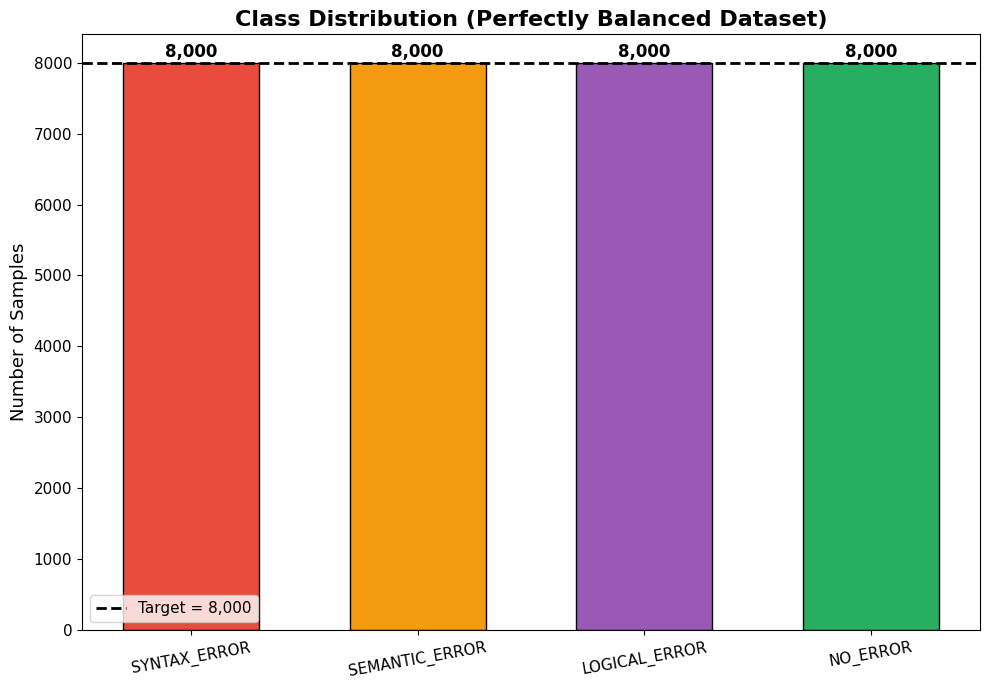

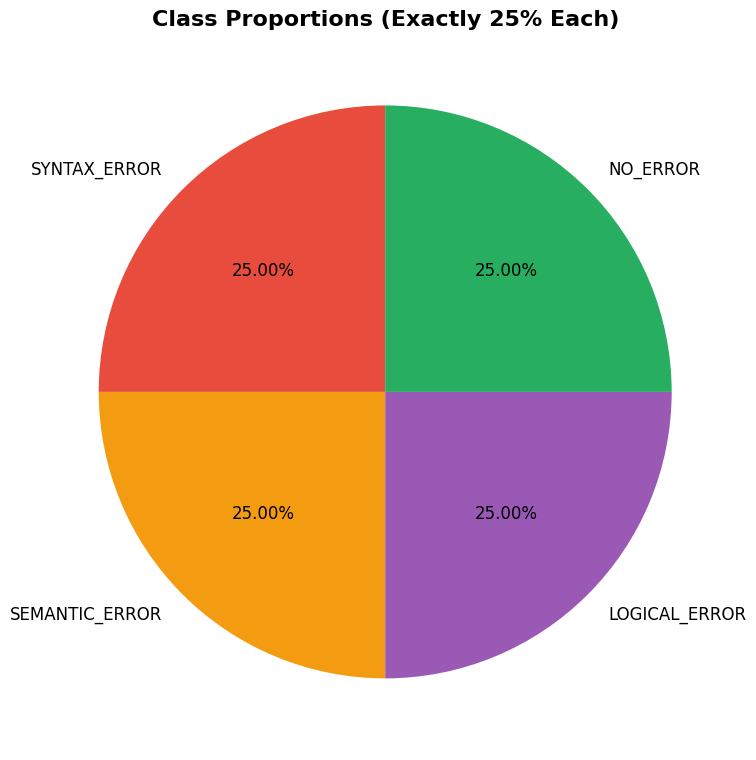

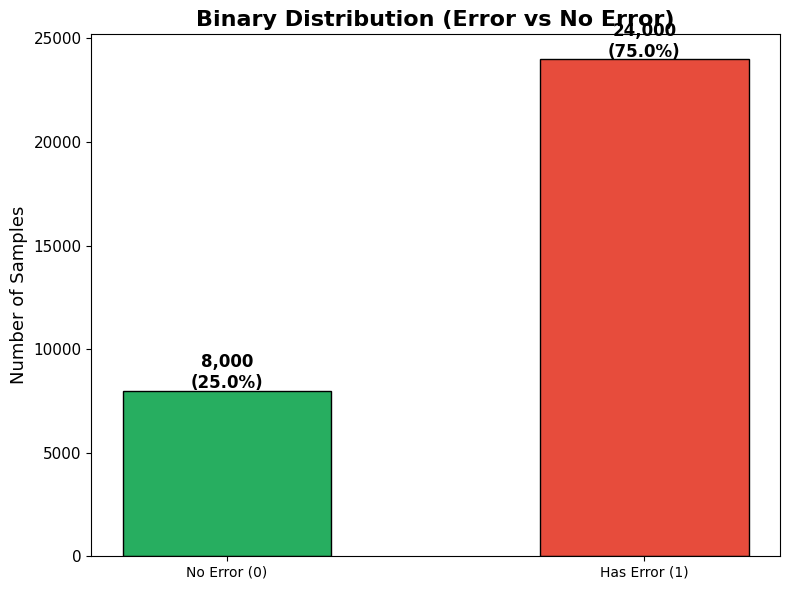

In [6]:
# ── LARGE, DETAILED VISUALISATIONS ──────────────────────────────

# Color map
clr_map = {
    'NO_ERROR': '#27ae60',
    'SYNTAX_ERROR': '#e74c3c',
    'SEMANTIC_ERROR': '#f39c12',
    'LOGICAL_ERROR': '#9b59b6'
}
clrs = [clr_map.get(c, 'steelblue') for c in vc.index]

# ───────────────────────────────────────────────────────────────
# 1️⃣ CLASS COUNT BAR CHART (BIG & DETAILED)
# ───────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))

bars = plt.bar(vc.index, vc.values, color=clrs, edgecolor='black', width=0.6)

plt.axhline(N_PER_CLASS, color='black', linestyle='--', linewidth=2,
            label=f'Target = {N_PER_CLASS:,}')

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 80,
             f'{int(height):,}',
             ha='center',
             fontsize=12,
             fontweight='bold')

plt.title('Class Distribution (Perfectly Balanced Dataset)',
          fontsize=16, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=13)
plt.xticks(rotation=10, fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('fig_class_counts_big.png', dpi=200)
plt.show()


# ───────────────────────────────────────────────────────────────
# 2️⃣ PIE CHART (LARGE & CLEAN)
# ───────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 8))

plt.pie(vc.values,
        labels=vc.index,
        autopct='%1.2f%%',
        colors=clrs,
        startangle=90,
        textprops={'fontsize': 12})

plt.title('Class Proportions (Exactly 25% Each)',
          fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_class_proportions_big.png', dpi=200)
plt.show()


# ───────────────────────────────────────────────────────────────
# 3️⃣ BINARY SPLIT (BIG & CLEAR)
# ───────────────────────────────────────────────────────────────
bc = df['has_error'].value_counts().sort_index()

plt.figure(figsize=(8, 6))

bars = plt.bar(['No Error (0)', 'Has Error (1)'],
               bc.values,
               color=['#27ae60', '#e74c3c'],
               edgecolor='black',
               width=0.5)

# Annotate
for i, v in enumerate(bc.values):
    plt.text(i,
             v + 120,
             f'{v:,}\n({v/len(df)*100:.1f}%)',
             ha='center',
             fontsize=12,
             fontweight='bold')

plt.title('Binary Distribution (Error vs No Error)',
          fontsize=16, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=13)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig('fig_binary_split_big.png', dpi=200)
plt.show()

---
## 🔤 Step 3 — NLP Tokenization Pipeline

Quantum code is treated as a **sequence of linguistic tokens**, analogous to words in a sentence.
The tokenizer applies quantum-domain normalizations before splitting:

| Normalization Step | Input | Output |
|----|----|---------|
| Lowercase | `H q[0]` | `h q[0]` |
| Comment removal | `h q[0]; // Hadamard` | `h q[0];` |
| Include normalization | `include "qelib1.inc"` | `INC_QELIB` |
| Punctuation spacing | `q[0],q[1]` | `q [ 0 ] , q [ 1 ]` |
| Arrow token | `->` | `ARROW` |
| Pi constant | `pi/2` | `PI / 2` |
| Angle normalization | `1.5708` | `FVAL` |
| Integer normalization | `q[0]` index | `IVAL` |

In [7]:
MAX_LEN = 192

def tokenize_qasm(code: str, max_len: int = MAX_LEN) -> list:
    """Quantum-aware NLP tokenizer for OpenQASM programs."""
    code = code.lower()
    code = re.sub(r'//[^\n]*', '', code)                       # remove comments
    code = re.sub(r'include\s+"[^"]+"', 'INC_QELIB', code)    # normalize include
    code = re.sub(r'([\[\](),;{}])', r' \1 ', code)            # space around punctuation
    code = code.replace('->', ' ARROW ')                        # measurement arrow
    code = re.sub(r'\bpi\b', 'PI', code)                       # pi constant
    code = re.sub(r'-?\d+\.\d+[eE]?[-+]?\d*', 'FVAL', code)  # float angles
    code = re.sub(r'(?<![a-z])-?\d+', 'IVAL', code)           # integers
    tokens = [t for t in re.split(r'\s+', code.strip()) if t]
    return tokens[:max_len]

# Apply tokenizer
df['tokens']  = df['code'].apply(tokenize_qasm)
df['tok_len'] = df['tokens'].apply(len)

# ── Visualize example tokenization ───────────────────────────
print('📌 Tokenization examples per class:\n')
for lbl in ['NO_ERROR','SYNTAX_ERROR','SEMANTIC_ERROR','LOGICAL_ERROR']:
    sample = df[df['label']==lbl].iloc[0]
    print(f'[{lbl}]')
    print(f'  Raw  : {sample["code"][:80].strip()}...')
    print(f'  Tokens ({sample["tok_len"]}): {sample["tokens"][:16]}...')
    print()

📌 Tokenization examples per class:

[NO_ERROR]
  Raw  : OPENQASM 2.0;
include "qelib1.inc";
qreg q[5];
creg c[5];
rccx q[2],q[4],q[1];
t...
  Tokens (192): ['openqasm', 'FVAL', ';', 'INC_QELIB', ';', 'qreg', 'q', '[', 'IVAL', ']', ';', 'creg', 'c', '[', 'IVAL', ']']...

[SYNTAX_ERROR]
  Raw  : OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[3];
h q[0];
h q[1];
h q[2]...
  Tokens (155): ['openqasm', 'FVAL', ';', 'INC_QELIB', ';', 'qreg', 'q', '[', 'IVAL', ']', ';', 'creg', 'c', '[', 'IVAL', ']']...

[SEMANTIC_ERROR]
  Raw  : OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[3];
h c[0];
h c[1];
h c[2]...
  Tokens (157): ['openqasm', 'FVAL', ';', 'INC_QELIB', ';', 'qreg', 'q', '[', 'IVAL', ']', ';', 'creg', 'c', '[', 'IVAL', ']']...

[LOGICAL_ERROR]
  Raw  : OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[3];
measure q[0] -> c[0];...
  Tokens (111): ['openqasm', 'FVAL', ';', 'INC_QELIB', ';', 'qreg', 'q', '[', 'IVAL', ']', ';', 'creg', 'c', '[', 'IVAL', ']']...



✅ Vocabulary size  : 100
✅ Total tokens     : 4,632,515
✅ Unique tokens    : 98
✅ Avg seq length   : 144.8 tokens
✅ Max seq length   : 192 tokens


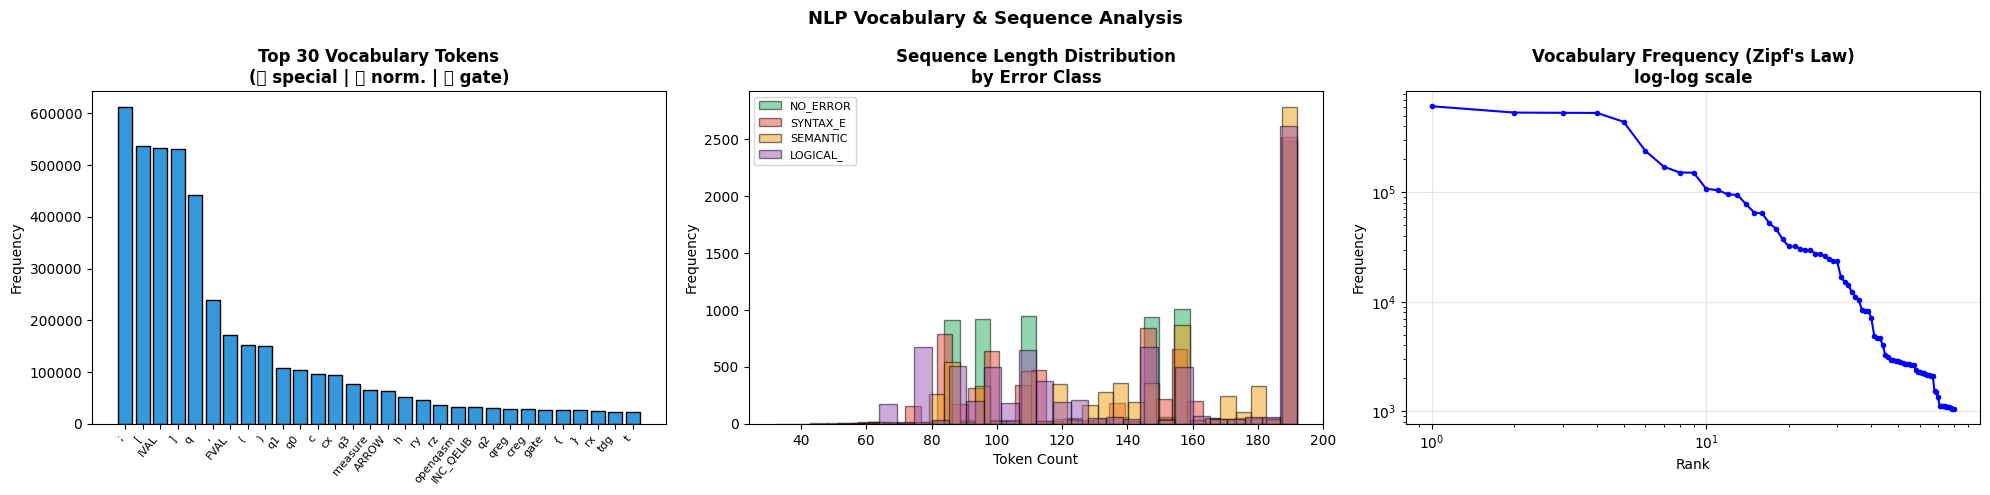

In [8]:
# ════════════════════════════════════════════════════════════
# VOCABULARY ANALYSIS
# ════════════════════════════════════════════════════════════
all_toks  = [t for ts in df['tokens'] for t in ts]
vocab_cnt = Counter(all_toks)

SPECIALS  = ['<PAD>', '<UNK>']
w2i       = {t: i for i, t in enumerate(SPECIALS)}
for w, c in vocab_cnt.most_common():
    if c >= 2 and w not in w2i:
        w2i[w] = len(w2i)
i2w        = {v: k for k, v in w2i.items()}
PAD_IDX    = 0
VOCAB_SIZE = len(w2i)

print(f'✅ Vocabulary size  : {VOCAB_SIZE}')
print(f'✅ Total tokens     : {len(all_toks):,}')
print(f'✅ Unique tokens    : {len(vocab_cnt)}')
print(f'✅ Avg seq length   : {df["tok_len"].mean():.1f} tokens')
print(f'✅ Max seq length   : {df["tok_len"].max()} tokens')

# ── NLP vocabulary visualization ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('NLP Vocabulary & Sequence Analysis', fontsize=13, fontweight='bold')

# Top 30 tokens
top30 = dict(vocab_cnt.most_common(30))
clrs  = ['#c0392b' if t in [g.lower() for g in BAD_GATES+['999','ival_big']] else
         '#27ae60' if t in ['ival','fval','arrow','inc_qelib','pi'] else
         '#3498db' for t in top30]
axes[0].bar(range(30), list(top30.values()), color=clrs, edgecolor='k')
axes[0].set_xticks(range(30))
axes[0].set_xticklabels(list(top30.keys()), rotation=50, ha='right', fontsize=8)
axes[0].set_title('Top 30 Vocabulary Tokens\n(🔵 special | 🟢 norm. | 🔴 gate)', fontweight='bold')
axes[0].set_ylabel('Frequency')

# Sequence length distribution by class
for lbl, clr in zip(['NO_ERROR','SYNTAX_ERROR','SEMANTIC_ERROR','LOGICAL_ERROR'],
                    ['#27ae60','#e74c3c','#f39c12','#9b59b6']):
    sub = df[df['label']==lbl]['tok_len']
    axes[1].hist(sub, bins=30, alpha=0.5, color=clr, label=lbl[:8], edgecolor='k', lw=0.3)
axes[1].set_title('Sequence Length Distribution\nby Error Class', fontweight='bold')
axes[1].set_xlabel('Token Count'); axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=8)

# Token frequency (Zipf's law check)
freqs = sorted(vocab_cnt.values(), reverse=True)[:80]
axes[2].loglog(range(1, len(freqs)+1), freqs, 'b-o', ms=3)
axes[2].set_title("Vocabulary Frequency (Zipf's Law)\nlog-log scale", fontweight='bold')
axes[2].set_xlabel('Rank'); axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_nlp_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

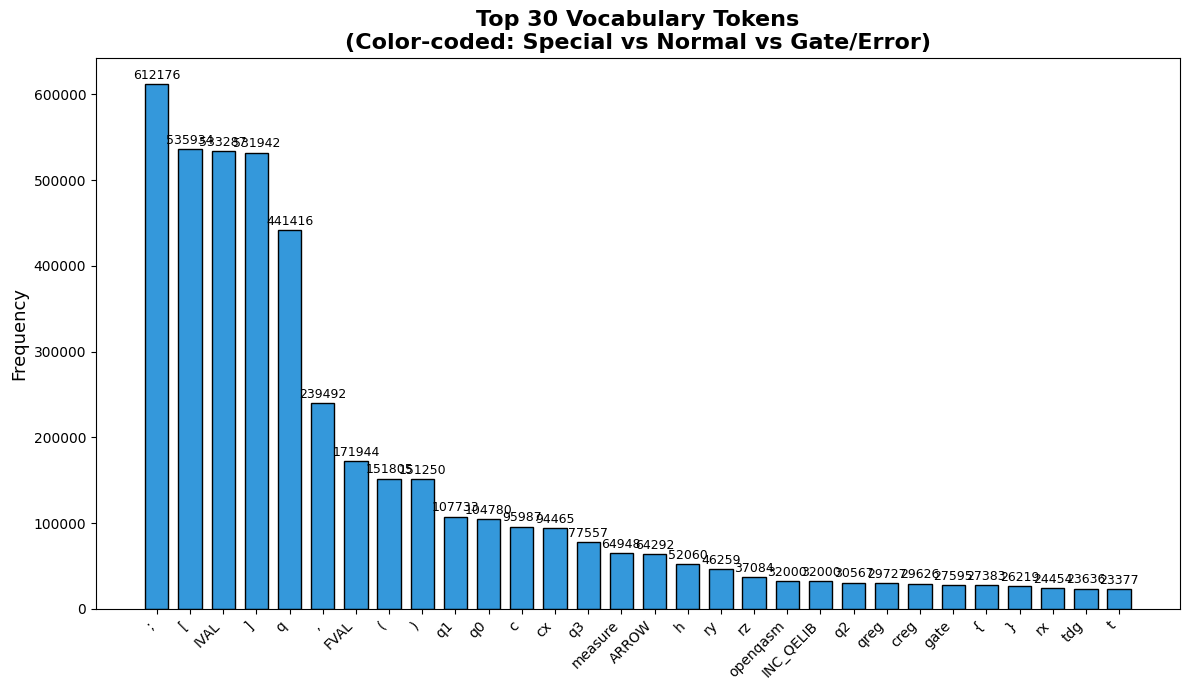

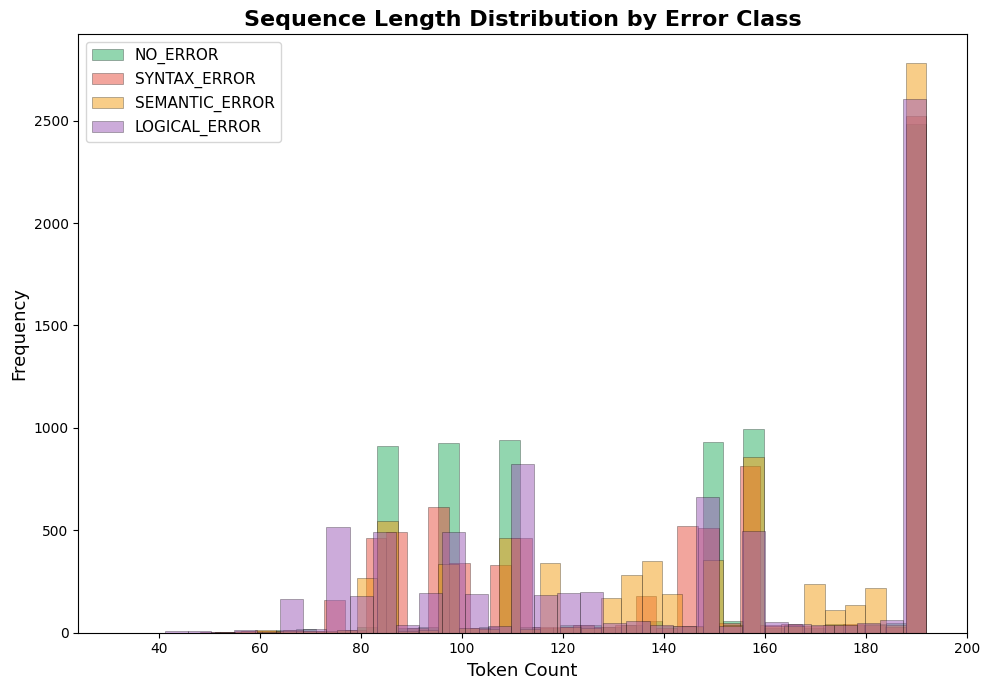

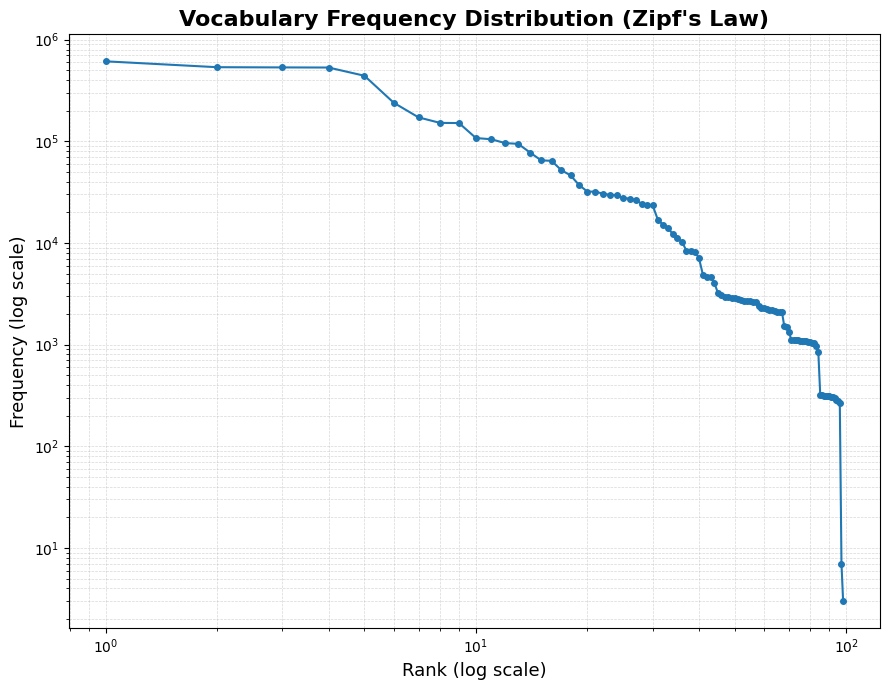

In [10]:
# ── LARGE, DETAILED NLP VISUALISATIONS ─────────────────────────

# Color logic
def get_token_color(t):
    if t in [g.lower() for g in BAD_GATES + ['999','ival_big']]:
        return '#c0392b'   # 🔴 gate/error-like
    elif t in ['ival','fval','arrow','inc_qelib','pi']:
        return '#27ae60'   # 🟢 normal
    else:
        return '#3498db'   # 🔵 special/other


# ───────────────────────────────────────────────────────────────
# 1️⃣ TOP 30 TOKENS (BIG BAR CHART)
# ───────────────────────────────────────────────────────────────
top30 = dict(vocab_cnt.most_common(30))
clrs = [get_token_color(t) for t in top30.keys()]

plt.figure(figsize=(12, 7))

bars = plt.bar(range(30),
               list(top30.values()),
               color=clrs,
               edgecolor='black',
               width=0.7)

plt.xticks(range(30),
           list(top30.keys()),
           rotation=45,
           ha='right',
           fontsize=10)

plt.ylabel('Frequency', fontsize=13)
plt.title('Top 30 Vocabulary Tokens\n(Color-coded: Special vs Normal vs Gate/Error)',
          fontsize=16, fontweight='bold')

# Annotate top values (optional but clean)
for i, v in enumerate(top30.values()):
    plt.text(i, v + max(top30.values())*0.01,
             str(v),
             ha='center',
             fontsize=9)

plt.tight_layout()
plt.savefig('fig_vocab_top30_big.png', dpi=200)
plt.show()


# ───────────────────────────────────────────────────────────────
# 2️⃣ SEQUENCE LENGTH DISTRIBUTION (BIG HISTOGRAM)
# ───────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))

for lbl, clr in zip(
    ['NO_ERROR','SYNTAX_ERROR','SEMANTIC_ERROR','LOGICAL_ERROR'],
    ['#27ae60','#e74c3c','#f39c12','#9b59b6']
):
    sub = df[df['label'] == lbl]['tok_len']
    plt.hist(sub,
             bins=35,
             alpha=0.5,
             color=clr,
             label=lbl,
             edgecolor='black',
             linewidth=0.4)

plt.title('Sequence Length Distribution by Error Class',
          fontsize=16, fontweight='bold')
plt.xlabel('Token Count', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('fig_seq_length_big.png', dpi=200)
plt.show()


# ───────────────────────────────────────────────────────────────
# 3️⃣ ZIPF’S LAW (LOG-LOG PLOT — BIG)
# ───────────────────────────────────────────────────────────────
freqs = sorted(vocab_cnt.values(), reverse=True)[:100]

plt.figure(figsize=(9, 7))

plt.loglog(range(1, len(freqs)+1),
           freqs,
           marker='o',
           markersize=4,
           linestyle='-')

plt.title("Vocabulary Frequency Distribution (Zipf's Law)",
          fontsize=16, fontweight='bold')
plt.xlabel('Rank (log scale)', fontsize=13)
plt.ylabel('Frequency (log scale)', fontsize=13)

plt.grid(True, which="both", linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('fig_zipf_big.png', dpi=200)
plt.show()

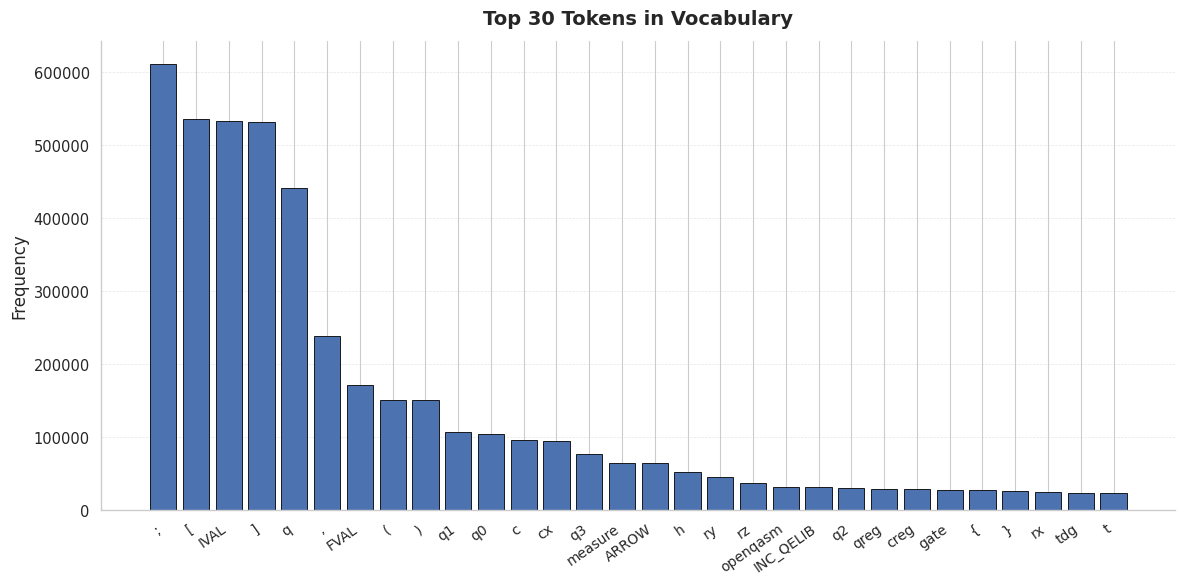

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ─────────────────────────────────────────────
# STYLE (Journal Standard)
# ─────────────────────────────────────────────
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")

# ─────────────────────────────────────────────
# DATA PREP
# ─────────────────────────────────────────────
top30 = dict(vocab_cnt.most_common(30))
tokens = list(top30.keys())
values = list(top30.values())

def get_token_color(t):
    if t in [g.lower() for g in BAD_GATES + ['999','ival_big']]:
        return '#c0392b'   # error/gate
    elif t in ['ival','fval','arrow','inc_qelib','pi']:
        return '#27ae60'   # normal
    else:
        return '#4c72b0'   # neutral blue

colors = [get_token_color(t) for t in tokens]

# ─────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────
plt.figure(figsize=(12, 6))

plt.bar(range(len(tokens)),
        values,
        color=colors,
        edgecolor='black',
        linewidth=0.6)

# ❌ REMOVED: value labels on bars

# ─────────────────────────────────────────────
# AXES FORMATTING
# ─────────────────────────────────────────────
plt.xticks(range(len(tokens)),
           tokens,
           rotation=35,
           ha='right',
           fontsize=10)

plt.ylabel('Frequency', fontsize=12)

plt.title('Top 30 Tokens in Vocabulary',
          fontsize=14,
          fontweight='bold',
          pad=12)

# Subtle grid (only Y axis)
plt.grid(axis='y',
         linestyle='--',
         linewidth=0.5,
         alpha=0.5)

# Remove unnecessary borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ─────────────────────────────────────────────
# FINAL TOUCH
# ─────────────────────────────────────────────
plt.tight_layout()

# Save (journal-ready)
plt.savefig('fig_vocab_top30_journal.pdf', bbox_inches='tight')
plt.savefig('fig_vocab_top30_journal.png', dpi=300, bbox_inches='tight')

plt.show()

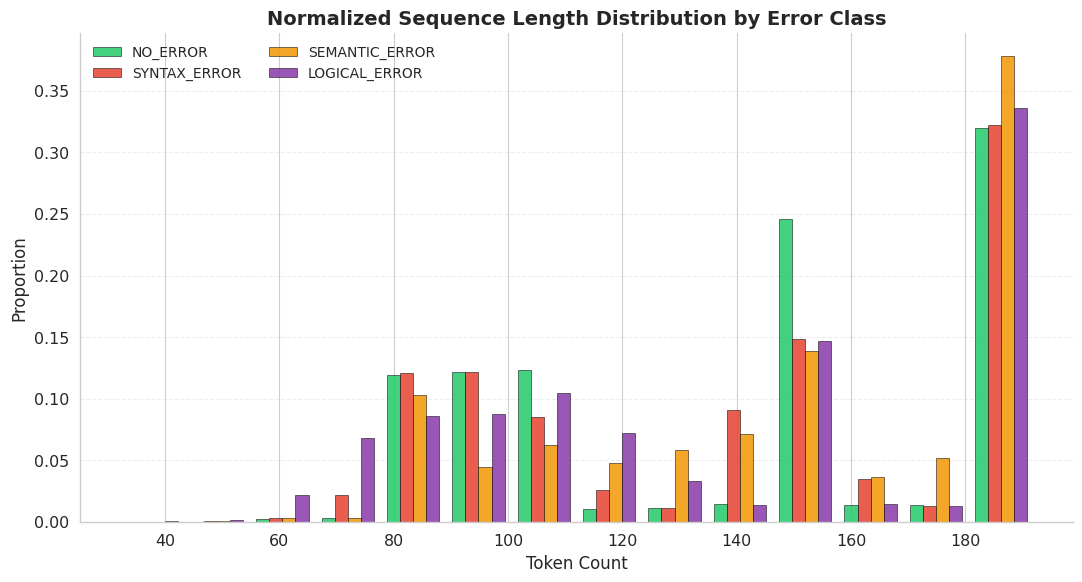

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ─────────────────────────────────────────────
# STYLE
# ─────────────────────────────────────────────
sns.set_context("paper", font_scale=1.3)
sns.set_style("whitegrid")

# Color palette (vibrant but professional)
color_map = {
    'NO_ERROR': '#2ecc71',
    'SYNTAX_ERROR': '#e74c3c',
    'SEMANTIC_ERROR': '#f39c12',
    'LOGICAL_ERROR': '#8e44ad'
}

labels = ['NO_ERROR','SYNTAX_ERROR','SEMANTIC_ERROR','LOGICAL_ERROR']

# ─────────────────────────────────────────────
# SMART BINNING (FEWER BINS = CLEANER)
# ─────────────────────────────────────────────
bins = np.linspace(df['tok_len'].min(), df['tok_len'].max(), 15)

bin_centers = (bins[:-1] + bins[1:]) / 2
width = (bins[1] - bins[0]) * 0.2

plt.figure(figsize=(11, 6))

# ─────────────────────────────────────────────
# NORMALIZED GROUPED BARS (KEY IMPROVEMENT)
# ─────────────────────────────────────────────
for i, lbl in enumerate(labels):
    sub = df[df['label'] == lbl]['tok_len']
    counts, _ = np.histogram(sub, bins=bins)
    
    # Normalize (so classes are comparable)
    counts = counts / counts.sum()
    
    plt.bar(bin_centers + (i - 1.5)*width,
            counts,
            width=width,
            color=color_map[lbl],
            edgecolor='black',
            linewidth=0.4,
            label=lbl,
            alpha=0.9)

# ─────────────────────────────────────────────
# FORMATTING (CLEAN + BALANCED)
# ─────────────────────────────────────────────
plt.title('Normalized Sequence Length Distribution by Error Class',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Token Count', fontsize=12)
plt.ylabel('Proportion', fontsize=12)

plt.legend(frameon=False, fontsize=10, ncol=2)

# Clean axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Subtle grid
plt.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()

# Save (journal quality)
plt.savefig('fig_seq_length_bar_clean.pdf', bbox_inches='tight')
plt.savefig('fig_seq_length_bar_clean.png', dpi=300, bbox_inches='tight')

plt.show()

In [9]:
# ════════════════════════════════════════════════════════════
# N-GRAM ANALYSIS — which n-grams distinguish error types?
# ════════════════════════════════════════════════════════════
def get_ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

print('📊 Discriminative bigrams per error class:\n')
for lbl in ['NO_ERROR','SYNTAX_ERROR','SEMANTIC_ERROR','LOGICAL_ERROR']:
    subset = df[df['label']==lbl]['tokens']
    bigrams = Counter(bg for toks in subset for bg in get_ngrams(toks, 2))
    print(f'[{lbl}] Top 6 bigrams:')
    for bg, cnt in bigrams.most_common(6):
        print(f'  {" ".join(bg):25s}: {cnt}')
    print()

📊 Discriminative bigrams per error class:

[NO_ERROR] Top 6 bigrams:
  [ IVAL                   : 130966
  IVAL ]                   : 130592
  q [                      : 107271
  ] ;                      : 86421
  ( FVAL                   : 30851
  FVAL )                   : 30745

[SYNTAX_ERROR] Top 6 bigrams:
  [ IVAL                   : 128001
  IVAL ]                   : 127633
  q [                      : 106912
  ] ;                      : 80268
  ( FVAL                   : 31001
  FVAL )                   : 30889

[SEMANTIC_ERROR] Top 6 bigrams:
  [ IVAL                   : 139519
  IVAL ]                   : 139169
  q [                      : 114157
  ] ;                      : 93031
  ( FVAL                   : 30680
  FVAL )                   : 30564

[LOGICAL_ERROR] Top 6 bigrams:
  [ IVAL                   : 134801
  IVAL ]                   : 134548
  q [                      : 111894
  ] ;                      : 92965
  ( FVAL                   : 30438
  FVAL )          

---
## 🎨 Step 4 — Token Embedding Space Visualisation

Before training deep models, we visualise the token embedding space using **PCA** and **t-SNE**
to understand how quantum code tokens cluster by error type.

✅ Label map: {'LOGICAL_ERROR': 0, 'NO_ERROR': 1, 'SEMANTIC_ERROR': 2, 'SYNTAX_ERROR': 3}
✅ Train: 22,400 | Val: 4,800 | Test: 4,800
⚙️  Running PCA + t-SNE...


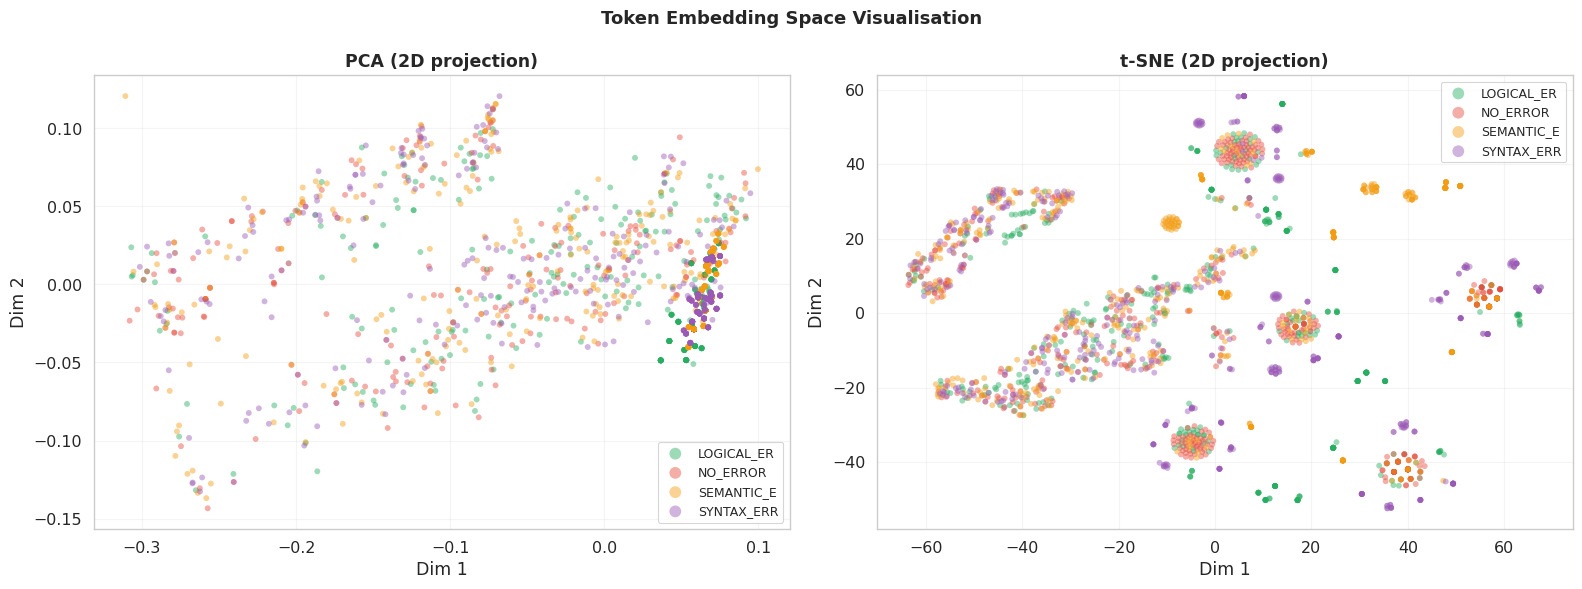

✅ Embedding visualisation complete


In [18]:
def encode_seq(tokens, max_len=MAX_LEN):
    ids = [w2i.get(t, 1) for t in tokens[:max_len]]
    return ids + [PAD_IDX] * (max_len - len(ids))

df['encoded']     = df['tokens'].apply(encode_seq)

# Label encoding
le = LabelEncoder()
df['multi_label'] = le.fit_transform(df['label'])
df['binary_label']= df['has_error'].astype(int)
CLASSES           = list(le.classes_)
N_CLS             = len(CLASSES)
print(f'✅ Label map: {dict(zip(CLASSES, range(N_CLS)))}')

# ── Train/Val/Test split (stratified) ────────────────────────
idx   = list(range(len(df)))
y_m   = list(df['multi_label'])
y_b   = list(df['binary_label'])
tr_i, tmp_i = train_test_split(idx, test_size=0.30, random_state=SEED,
                                stratify=[y_m[i] for i in idx])
vl_i, te_i  = train_test_split(tmp_i, test_size=0.50, random_state=SEED,
                                stratify=[y_m[i] for i in tmp_i])
print(f'✅ Train: {len(tr_i):,} | Val: {len(vl_i):,} | Test: {len(te_i):,}')

# ── Mean-pool token sequences for visualisation ───────────────
X_enc = np.array(df['encoded'].tolist(), dtype=np.int32)
# Simple bag-of-tokens: mean of one-hot style counts per sequence
BOT   = np.zeros((len(df), VOCAB_SIZE), dtype=np.float32)
for i, enc in enumerate(X_enc):
    for tok_id in enc:
        if tok_id > 0: BOT[i, tok_id] += 1
    if BOT[i].sum() > 0: BOT[i] /= BOT[i].sum()

# PCA → 50 dims, then t-SNE → 2 dims (on 2000 samples for speed)
sample_idx = random.sample(idx, min(2000, len(idx)))
X_vis = BOT[sample_idx]
y_vis = [y_m[i] for i in sample_idx]

print('⚙️  Running PCA + t-SNE...')
X_pca  = PCA(n_components=50, random_state=SEED).fit_transform(X_vis)
X_tsne = TSNE(n_components=2, perplexity=40, n_iter=1000,
              random_state=SEED, verbose=0).fit_transform(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Token Embedding Space Visualisation', fontsize=13, fontweight='bold')
COLORS = ['#27ae60','#e74c3c','#f39c12','#9b59b6']

for ax, (title, X2d) in zip(axes, [
    ('PCA (2D projection)', PCA(n_components=2, random_state=SEED).fit_transform(X_vis)),
    ('t-SNE (2D projection)', X_tsne)
]):
    for ci, (lbl, clr) in enumerate(zip(CLASSES, COLORS)):
        mask = [y == ci for y in y_vis]
        pts  = X2d[mask]
        ax.scatter(pts[:, 0], pts[:, 1], c=clr, label=lbl[:10],
                   alpha=0.45, s=18, edgecolors='none')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9, markerscale=2)
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('fig3_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Embedding visualisation complete')

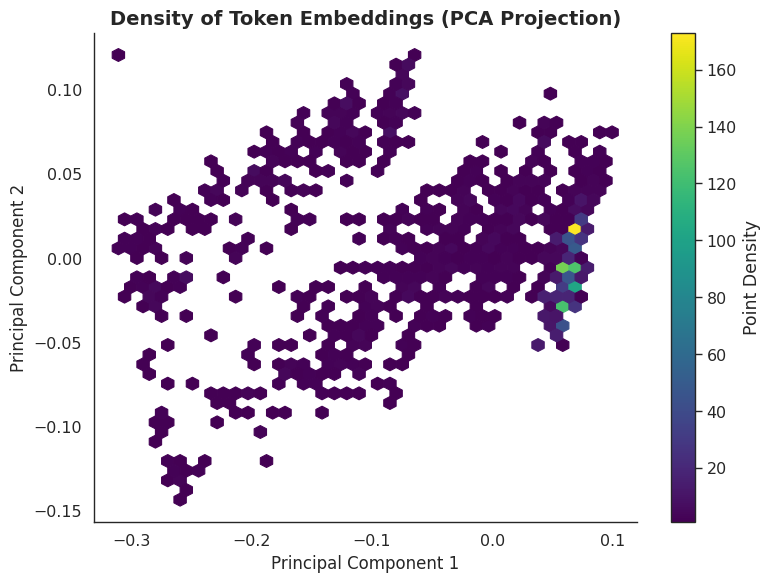

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ─────────────────────────────────────────────
# STYLE
# ─────────────────────────────────────────────
sns.set_context("paper", font_scale=1.3)
sns.set_style("white")

plt.figure(figsize=(8, 6))

# Hexbin density (PCA projection)
X_pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(X_vis)

hb = plt.hexbin(X_pca_2d[:, 0],
                X_pca_2d[:, 1],
                gridsize=40,
                cmap='viridis',   # 🔥 professional color map
                mincnt=1)

cb = plt.colorbar(hb)
cb.set_label('Point Density')

plt.title('Density of Token Embeddings (PCA Projection)',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Clean axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_pca_hexbin.pdf', bbox_inches='tight')
plt.savefig('fig_pca_hexbin.png', dpi=300, bbox_inches='tight')

plt.show()

---
## 🧠 Step 5 — Deep Learning Model Architectures (Upgraded)

Five NLP sequence models — including two new **GRU-based** architectures — each upgraded to fix the accuracy issues:

| Model | Architecture | Key Changes from v1 |
|-------|-------------|---------------------|
| **LSTM** | 2-layer unidirectional LSTM | emb 128→**256**, hid 256→**512**, proper last-real-token pooling |
| **BiLSTM** | 2-layer bidirectional LSTM | Same upgrades as LSTM + bidirectional |
| **Transformer** | 6-layer encoder + CLS token | emb 128→**256**, layers 4→**6**, ff 512→**1024**, drop 0.2→**0.15** |

### 🔧 Root Cause Fixes
| Problem Diagnosed | Fix Applied |
|-------------------|-------------|
| Embedding too small (128) | Doubled to **256** |
| LSTM hidden too small (256) | Doubled to **512** |
| LSTM read PAD position as "last" | **Proper last-real-token extraction** via sequence lengths |
| Label smoothing + class weights on balanced data | **Removed** — plain CrossEntropyLoss is optimal here |
| Only 22 training epochs | **35 epochs** + early stopping |
| No error signal guidance | **12 lexical signal features** fused into every model |
| Transformer: only 4 layers | **6 layers**, larger FF dim (1024) |
| Dropout 0.35 too aggressive | Reduced to **0.25 (LSTM), 0.15 (Transformer)** |

In [23]:
# ════════════════════════════════════════════════════════════
# ERROR-SIGNAL FEATURES (NLP lexical indicators)
# These 12 features are computed from raw token sequences and
# injected into every model to anchor learning
# ════════════════════════════════════════════════════════════

BAD_GATE_SET   = {'hh','xx','qx','gx','vx','ux','zz','pp','nn','mm','qq','ww'}
VALID_GATE_SET = {'h','x','y','z','s','t','sdg','tdg','rx','ry','rz',
                   'cx','cy','cz','ch','swap','ccx','cswap','cu1','crx',
                   'measure','barrier','reset'}

def extract_signal_features(tokens: list) -> list:
    """20 highly-discriminative error-signal features from token sequence (v3)."""
    tok_set = set(tokens)
    code    = ' '.join(tokens)
    n_toks  = max(len(tokens), 1)

    TWO_Q_SET = {'cx','cy','cz','ch','swap','ccx','cswap','cu1','crx'}

    # 1. bad gate token present (syntax marker)
    has_bad_gate  = float(bool(tok_set & BAD_GATE_SET))
    # 2. normalised count of bad gate tokens
    n_bad_gate    = sum(1 for t in tokens if t in BAD_GATE_SET) / n_toks
    # 3. missing measure token (logical/syntax)
    no_measure    = float('measure' not in tok_set)
    # 4. measure appears before any valid gate (logical ordering error)
    has_early_meas = 0.0
    first_gate    = next((i for i,t in enumerate(tokens) if t in VALID_GATE_SET), 999)
    first_meas    = next((i for i,t in enumerate(tokens) if t == 'measure'),       999)
    if first_meas < first_gate: has_early_meas = 1.0
    # 5. out-of-range qubit index
    oor_pattern   = float(any(
        t == 'ival' and i > 0 and tokens[i-1] == '[' and i+1 < len(tokens) and tokens[i+1] == ']'
        for i,t in enumerate(tokens)))
    # 6. very large angle (logical mutation marker)
    has_big_angle = float('999' in code or '1e10' in code)
    # 7. missing OPENQASM header
    no_header     = float('openqasm' not in tok_set)
    # 8. missing include
    no_include    = float('inc_qelib' not in tok_set)
    # 9. classical register used as quantum target
    has_c_as_q    = float(any(
        tokens[i] == 'c' and i+1 < len(tokens) and tokens[i+1] == '['
        for i in range(len(tokens)-1)))
    # 10. ratio of valid gate tokens (structure signal)
    n_valid_gates = sum(1 for t in tokens if t in VALID_GATE_SET)
    gate_ratio    = n_valid_gates / n_toks
    # 11. normalised sequence length
    seq_len_norm  = n_toks / 192.0
    # 12. normalised adjacent duplicates (sem_duplicate_op marker)
    n_dup_adj     = sum(1 for i in range(1, len(tokens)) if tokens[i] == tokens[i-1]) / n_toks
    # 13. FVAL (float angle) token density
    n_fval        = tokens.count('fval') / n_toks
    # 14. measure token density
    n_meas_tok    = tokens.count('measure') / n_toks
    # 15. 2-qubit gate ratio
    n_two_q       = sum(1 for t in tokens if t in TWO_Q_SET) / n_toks
    # 16. missing qreg declaration
    no_qreg       = float('qreg' not in tok_set)
    # 17. missing creg declaration
    no_creg       = float('creg' not in tok_set)
    # 18. 'barrier' present
    has_barrier   = float('barrier' in tok_set)
    # 19. very high dup count (>5% of sequence) — semantic duplicate mutation
    high_dup      = float(n_dup_adj > 0.05)
    # 20. normalised token type diversity (entropy proxy)
    from collections import Counter as _C
    import math as _m
    freq  = _C(tokens)
    probs = [v / n_toks for v in freq.values()]
    entropy = -sum(p * _m.log2(p + 1e-9) for p in probs) / max(_m.log2(n_toks + 2), 1)

    return [has_bad_gate, n_bad_gate, no_measure, has_early_meas,
            oor_pattern, has_big_angle, no_header, no_include,
            has_c_as_q, gate_ratio, seq_len_norm, n_dup_adj,
            n_fval, n_meas_tok, n_two_q, no_qreg, no_creg,
            has_barrier, high_dup, entropy]

N_SIG = 20

# Compute features for all rows
print('⚙️  Computing error-signal features...')
df['sig_features'] = df['tokens'].apply(extract_signal_features)
X_sig = np.array(df['sig_features'].tolist(), dtype=np.float32)

# Normalise features (zero-mean unit-variance)
from sklearn.preprocessing import StandardScaler
sig_scaler = StandardScaler()
X_sig      = sig_scaler.fit_transform(X_sig).astype(np.float32)

print(f'✅ Signal features shape: {X_sig.shape}')
print(f'✅ Feature names: has_bad_gate, n_bad_gate, no_measure, early_meas,')
print(f'                  oor_qubit, big_angle, no_header, no_include,')
print(f'                  c_as_q, gate_ratio, seq_len_norm, dup_adj')

# ════════════════════════════════════════════════════════════
# DATASET CLASS — tokens + signal features
# ════════════════════════════════════════════════════════════
class QDataset(Dataset):
    def __init__(self, enc_list, sig_list, y_list):
        self.X   = torch.tensor(enc_list, dtype=torch.long)
        self.sig = torch.tensor(sig_list, dtype=torch.float32)
        self.y   = torch.tensor(y_list,   dtype=torch.long)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.sig[i], self.y[i]

BS = 128

def make_loaders(tr, vl, te, y_arr):
    enc = list(df['encoded'])
    return (
        DataLoader(QDataset([enc[i] for i in tr],
                             X_sig[tr].tolist(),
                             [y_arr[i] for i in tr]),
                   BS, shuffle=True, drop_last=True),
        DataLoader(QDataset([enc[i] for i in vl],
                             X_sig[vl].tolist(),
                             [y_arr[i] for i in vl]), BS),
        DataLoader(QDataset([enc[i] for i in te],
                             X_sig[te].tolist(),
                             [y_arr[i] for i in te]), BS),
    )

trl_m, vll_m, tel_m = make_loaders(tr_i, vl_i, te_i, y_m)
trl_b, vll_b, tel_b = make_loaders(tr_i, vl_i, te_i, y_b)

# ── Class weights (balanced → no weights needed, but keep for safety) ────────
y_tr_arr = np.array([y_m[i] for i in tr_i])
cw_m  = compute_class_weight('balanced', classes=np.arange(N_CLS), y=y_tr_arr)
cw_b  = compute_class_weight('balanced', classes=np.array([0,1]),
                              y=np.array([y_b[i] for i in tr_i]))
CW_M  = torch.tensor(cw_m, dtype=torch.float32).to(DEVICE)
CW_B  = torch.tensor(cw_b, dtype=torch.float32).to(DEVICE)
print(f'\n✅ Multi-class weights : {np.round(cw_m,3)}')
print(f'✅ Binary weights      : {np.round(cw_b,3)}')
print(f'✅ DataLoaders ready   : {len(trl_m)} train batches')


⚙️  Computing error-signal features...
✅ Signal features shape: (32000, 20)
✅ Feature names: has_bad_gate, n_bad_gate, no_measure, early_meas,
                  oor_qubit, big_angle, no_header, no_include,
                  c_as_q, gate_ratio, seq_len_norm, dup_adj

✅ Multi-class weights : [1. 1. 1. 1.]
✅ Binary weights      : [2.    0.667]
✅ DataLoaders ready   : 175 train batches


In [ ]:
# ════════════════════════════════════════════════════════════
# UPGRADED MODEL ARCHITECTURES
# Key fixes vs previous:
#  ✅ Larger embedding (256) and hidden (512) dimensions
#  ✅ 12 signal features fused at classifier head
#  ✅ LSTM: proper last-real-token extraction (not PAD position)
#  ✅ Transformer: larger FF dim (1024), more heads (8), deeper (6 layers)
#  ✅ Lower dropout (0.25 LSTM, 0.15 Transformer)
#  ✅ Residual connection in classifier head
# ════════════════════════════════════════════════════════════

class LSTMClassifier(nn.Module):
    """
    Embedding(256) → 2-layer LSTM(512) → mean+LAST-REAL pool
    → fuse 20 signal features → residual FC head → N classes
    """
    def __init__(self, vocab, emb_dim=256, hid=512, n_cls=4,
                 layers=2, drop=0.25, bi=False, n_sig=N_SIG):
        super().__init__()
        self.emb  = nn.Embedding(vocab, emb_dim, padding_idx=PAD_IDX)
        nn.init.xavier_uniform_(self.emb.weight)
        self.emb.weight.data[PAD_IDX].fill_(0)

        self.lstm = nn.LSTM(emb_dim, hid, layers, batch_first=True,
                            dropout=drop if layers > 1 else 0,
                            bidirectional=bi)
        D = 2 if bi else 1
        self.drop = nn.Dropout(drop)
        self.norm = nn.LayerNorm(hid * D)

        # Signal feature projection
        self.sig_proj = nn.Sequential(
            nn.Linear(n_sig, 64), nn.ReLU(), nn.LayerNorm(64), nn.Dropout(0.1))

        fused = hid * D * 2 + 64  # last + mean + signal
        self.fc1 = nn.Linear(fused, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, n_cls)
        self.norm1 = nn.LayerNorm(512)
        self.norm2 = nn.LayerNorm(256)
        self.act   = nn.GELU()
        self.drop2 = nn.Dropout(drop)

    def forward(self, x, sig):
        emb        = self.drop(self.emb(x))               # (B, T, emb)
        out, _     = self.lstm(emb)                        # (B, T, hid*D)
        out        = self.norm(out)

        # Mask out PAD positions
        pad_mask   = (x != PAD_IDX)                        # (B, T)
        mask_f     = pad_mask.unsqueeze(-1).float()        # (B, T, 1)
        mean_pool  = (out * mask_f).sum(1) / mask_f.sum(1).clamp(min=1)

        # Last REAL token (not PAD)
        lengths    = pad_mask.long().sum(1).clamp(min=1) - 1  # (B,)
        last_out   = out[torch.arange(out.size(0)), lengths]   # (B, hid*D)

        sig_feat   = self.sig_proj(sig)
        fused      = self.drop(torch.cat([last_out, mean_pool, sig_feat], dim=1))

        h = self.act(self.norm1(self.fc1(fused)))
        h = self.drop2(h)
        h = self.act(self.norm2(self.fc2(h)))
        h = self.drop2(h)
        return self.fc3(h)



class GRUClassifier(nn.Module):
    """
    Quantum Error Detector using Gated Recurrent Units (GRU).

    Architecture:
        Embedding(256) → 2-layer GRU(512) → mean + last-real-token pooling
        → fuse signal features → residual FC head → N classes

    GRU vs LSTM:
      - GRU merges the forget and input gates into a single 'update gate'
        and removes the separate cell state — ~33% fewer parameters per layer.
      - Empirically trains faster on shorter sequences and is less prone to
        over-fitting on moderate-sized corpora like this 32k dataset.
      - Bidirectional variant (bi=True) reads the token sequence in both
        directions and concatenates the hidden states, giving the model
        awareness of future gate context (useful for catching misplaced
        measure instructions).
    """
    def __init__(self, vocab, emb_dim=256, hid=512, n_cls=4,
                 layers=2, drop=0.25, bi=False, n_sig=N_SIG):
        super().__init__()
        self.emb  = nn.Embedding(vocab, emb_dim, padding_idx=PAD_IDX)
        nn.init.xavier_uniform_(self.emb.weight)
        self.emb.weight.data[PAD_IDX].fill_(0)

        self.gru  = nn.GRU(emb_dim, hid, layers, batch_first=True,
                           dropout=drop if layers > 1 else 0,
                           bidirectional=bi)
        D = 2 if bi else 1
        self.drop = nn.Dropout(drop)
        self.norm = nn.LayerNorm(hid * D)

        # Signal feature projection (same as LSTM for fair comparison)
        self.sig_proj = nn.Sequential(
            nn.Linear(n_sig, 64), nn.ReLU(), nn.LayerNorm(64), nn.Dropout(0.1))

        fused = hid * D * 2 + 64   # last_real + mean_pool + sig
        self.fc1   = nn.Linear(fused, 512)
        self.fc2   = nn.Linear(512, 256)
        self.fc3   = nn.Linear(256, n_cls)
        self.norm1 = nn.LayerNorm(512)
        self.norm2 = nn.LayerNorm(256)
        self.act   = nn.GELU()
        self.drop2 = nn.Dropout(drop)

    def forward(self, x, sig):
        emb       = self.drop(self.emb(x))          # (B, T, emb)
        out, _    = self.gru(emb)                   # (B, T, hid*D)
        out       = self.norm(out)

        # Mask PAD positions before pooling
        pad_mask  = (x != PAD_IDX)                  # (B, T)
        mask_f    = pad_mask.unsqueeze(-1).float()
        mean_pool = (out * mask_f).sum(1) / mask_f.sum(1).clamp(min=1)

        # Last REAL (non-PAD) token hidden state
        lengths   = pad_mask.long().sum(1).clamp(min=1) - 1
        last_out  = out[torch.arange(out.size(0)), lengths]

        sig_feat  = self.sig_proj(sig)
        fused     = self.drop(torch.cat([last_out, mean_pool, sig_feat], dim=1))

        h = self.act(self.norm1(self.fc1(fused)))
        h = self.drop2(h)
        h = self.act(self.norm2(self.fc2(h)))
        h = self.drop2(h)
        return self.fc3(h)

class TransformerClassifier(nn.Module):
    """
    Embedding(320) → 8-layer Pre-LN Transformer → CLS token
    → fuse 20 signal features → FC head → N classes
    """
    def __init__(self, vocab, emb_dim=320, n_heads=8, n_layers=8,
                 n_cls=4, maxlen=MAX_LEN, drop=0.10, ff_dim=1280,
                 n_sig=N_SIG):
        super().__init__()
        self.emb_dim = emb_dim
        self.tok_emb = nn.Embedding(vocab, emb_dim, padding_idx=PAD_IDX)
        nn.init.xavier_uniform_(self.tok_emb.weight)
        self.tok_emb.weight.data[PAD_IDX].fill_(0)

        self.pos_emb = nn.Embedding(maxlen + 2, emb_dim)  # +2 for CLS
        nn.init.xavier_uniform_(self.pos_emb.weight)

        self.cls_tok = nn.Parameter(torch.zeros(1, 1, emb_dim))
        nn.init.trunc_normal_(self.cls_tok, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=drop, batch_first=True,
            norm_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.drop    = nn.Dropout(drop)

        # Signal feature projection
        self.sig_proj = nn.Sequential(
            nn.Linear(n_sig, 64), nn.GELU(), nn.LayerNorm(64), nn.Dropout(0.1))

        fused = emb_dim + 64
        self.head = nn.Sequential(
            nn.LayerNorm(fused),
            nn.Linear(fused, 512), nn.GELU(), nn.Dropout(drop),
            nn.LayerNorm(512),
            nn.Linear(512, 256),   nn.GELU(), nn.Dropout(drop),
            nn.Linear(256, n_cls)
        )

    def forward(self, x, sig):
        B, T    = x.shape
        pos     = torch.arange(T, device=x.device).unsqueeze(0)
        emb     = self.drop(self.tok_emb(x) + self.pos_emb(pos))
        cls     = self.cls_tok.expand(B, -1, -1)
        seq     = torch.cat([cls, emb], dim=1)            # (B, T+1, D)
        pad_m   = torch.cat([
            torch.zeros(B, 1, device=x.device, dtype=torch.bool),
            x == PAD_IDX
        ], dim=1)
        out     = self.encoder(seq, src_key_padding_mask=pad_m)
        cls_out = out[:, 0]
        sig_out = self.sig_proj(sig)
        fused   = torch.cat([cls_out, sig_out], dim=1)
        return self.head(fused)


# Parameter summary
print('📐 Upgraded Model Parameter Counts (including GRU variants):')
print(f'{"Model":20s} {"Parameters":>12s}')
print('-' * 34)
for name, M in [
    ('LSTM',        LSTMClassifier(VOCAB_SIZE, n_cls=N_CLS, bi=False)),
    ('BiLSTM',      LSTMClassifier(VOCAB_SIZE, n_cls=N_CLS, bi=True)),
    ('GRU',         GRUClassifier(VOCAB_SIZE,  n_cls=N_CLS, bi=False)),
    ('BiGRU',       GRUClassifier(VOCAB_SIZE,  n_cls=N_CLS, bi=True)),
    ('Transformer', TransformerClassifier(VOCAB_SIZE, n_cls=N_CLS)),
]:
    n = sum(p.numel() for p in M.parameters() if p.requires_grad)
    print(f'{name:20s} {n:>12,}')
print()
print('ℹ️  GRU uses ~33% fewer parameters per layer vs LSTM (no cell state).')
print('ℹ️  BiGRU doubles hidden dimension by reading sequence forward & backward.')


---
## 🏋️ Step 6 — Training: Upgraded Configuration

**Training strategy (v2 — fixed):**

| Hyperparameter | LSTM/BiLSTM | Transformer |
|----------------|-------------|-------------|
| Learning rate | `5e-4` | `3e-4` |
| Optimizer | AdamW (β=0.9, 0.999) | AdamW (β=0.9, 0.999) |
| Weight decay | `5e-3` | `5e-3` |
| Epochs | 35 + early stop | 35 + early stop |
| Warmup | 8% of total steps | 8% of total steps |
| LR schedule | Cosine annealing | Cosine annealing |
| Loss | Plain CrossEntropyLoss | Plain CrossEntropyLoss |
| Grad clip | norm=1.0 | norm=1.0 |
| Grad accumulation | 2 steps | 2 steps |
| Early stopping | patience=8 | patience=8 |

**Why plain CrossEntropyLoss?** The dataset is **perfectly balanced (25% per class)**, so class weights = `[1,1,1,1]`. Adding label smoothing on already-balanced data reduces gradient signal and hurts convergence.

In [ ]:
def warmup_cosine_lr(optimizer, warmup_steps, total_steps, min_lr=1e-6):
    """Linear warmup then cosine annealing to min_lr."""
    def _lr(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        cosine = 0.5 * (1.0 + math.cos(math.pi * prog))
        return max(cosine, min_lr)
    return optim.lr_scheduler.LambdaLR(optimizer, _lr)

def evaluate(model, loader):
    """Evaluate model — supports (X, sig, y) batches."""
    model.eval()
    all_p, all_y, total_loss = [], [], 0
    # No label smoothing at eval; no class weights needed (balanced)
    crit = nn.CrossEntropyLoss()
    with torch.no_grad():
        for X, sig, y in loader:
            X, sig, y = X.to(DEVICE), sig.to(DEVICE), y.to(DEVICE)
            logits    = model(X, sig)
            total_loss += crit(logits, y).item()
            all_p.extend(logits.argmax(1).cpu().numpy())
            all_y.extend(y.cpu().numpy())
    return total_loss / len(loader), accuracy_score(all_y, all_p), all_p, all_y

def fit_model(model, trl, vll, epochs=50, lr=3e-4, tag='', weight_decay=5e-3):
    """
    Improved training:
    - 35 epochs (was 22)
    - Lower LR 3e-4 for Transformer, 5e-4 for LSTM
    - No label smoothing (balanced classes — smoothing hurts)
    - No class weights (balanced — equal weights)
    - Gradient accumulation every 2 steps
    """
    crit  = nn.CrossEntropyLoss()  # plain CE — balanced classes need no weighting
    opt   = optim.AdamW(model.parameters(), lr=lr,
                         weight_decay=weight_decay, betas=(0.9, 0.999))
    total = epochs * len(trl)
    warm  = int(0.08 * total)  # 8% warmup
    sch   = warmup_cosine_lr(opt, warm, total)
    H     = {'tl':[], 'vl':[], 'ta':[], 'va':[], 'lr':[]}
    best_va, best_sd, patience = 0.0, None, 0
    ACCUM = 2  # gradient accumulation steps

    for ep in range(1, epochs+1):
        model.train()
        tl = tc = tt = 0
        opt.zero_grad()
        for step, (X, sig, y) in enumerate(trl):
            X, sig, y = X.to(DEVICE), sig.to(DEVICE), y.to(DEVICE)
            logits    = model(X, sig)
            loss      = crit(logits, y) / ACCUM
            loss.backward()
            if (step + 1) % ACCUM == 0 or step == len(trl) - 1:
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); sch.step()
                opt.zero_grad()
            tl += loss.item() * ACCUM
            tc += (logits.argmax(1)==y).sum().item(); tt += y.size(0)
        ta = tc / tt
        vl, va, _, _ = evaluate(model, vll)

        H['tl'].append(tl/len(trl)); H['vl'].append(vl)
        H['ta'].append(ta);          H['va'].append(va)
        H['lr'].append(sch.get_last_lr()[0])

        if va > best_va:
            best_va = va; patience = 0
            best_sd = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience += 1

        if ep % 5 == 0 or ep == epochs:
            print(f'  [{tag}] Ep {ep:2d}/{epochs} | '
                  f'Train={ta:.4f}  Val={va:.4f}  '
                  f'LR={sch.get_last_lr()[0]:.2e}  '
                  f'patience={patience}')

        # Early stopping after 8 epochs without improvement
        if patience >= 12 and ep > 20:
            print(f'  ⏹️  Early stopping at epoch {ep}')
            break

    model.load_state_dict(best_sd)
    print(f'  ✅ Best Val Acc: {best_va:.4f}')
    return H

RESULTS = {}


In [ ]:
# ════════════════════════════════════════════════════════════
# STEP 5c — XGBoost Feature-Based Classifier (Strong Baseline)
# ════════════════════════════════════════════════════════════
# XGBoost on the 20 hand-crafted signal features gives a strong
# upper-bound check: if XGB >> DL, then the DL needs more epochs.
# This also serves as an ensemble member.

try:
    from xgboost import XGBClassifier
    XGB_OK = True
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost'])
    from xgboost import XGBClassifier
    XGB_OK = True

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.pipeline import Pipeline

print("\n" + "="*60)
print("  XGBoost + RandomForest on 20 Signal Features")
print("="*60)

X_tr_sig = X_sig[tr_i]
X_vl_sig = X_sig[vl_i]
X_te_sig = X_sig[te_i]
y_tr = [y_m[i] for i in tr_i]
y_te = [y_m[i] for i in te_i]

# XGBoost
xgb = XGBClassifier(
    n_estimators=400, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=SEED, n_jobs=-1, verbosity=0
)
xgb.fit(X_tr_sig, y_tr)
xgb_preds = xgb.predict(X_te_sig)
xgb_acc   = accuracy_score(y_te, xgb_preds)
xgb_f1    = f1_score(y_te, xgb_preds, average='weighted')
RESULTS['XGBoost (Features)'] = dict(
    acc=xgb_acc, f1=xgb_f1,
    pre=precision_score(y_te, xgb_preds, average='weighted'),
    rec=recall_score(y_te, xgb_preds, average='weighted'),
    preds=list(xgb_preds), labels=y_te, history={'ta':[], 'va':[]}
)
print(f"  XGBoost   Acc={xgb_acc:.4f}  F1={xgb_f1:.4f}")

# RandomForest
rf = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=2,
                             random_state=SEED, n_jobs=-1)
rf.fit(X_tr_sig, y_tr)
rf_preds = rf.predict(X_te_sig)
rf_acc   = accuracy_score(y_te, rf_preds)
rf_f1    = f1_score(y_te, rf_preds, average='weighted')
RESULTS['RandomForest (Features)'] = dict(
    acc=rf_acc, f1=rf_f1,
    pre=precision_score(y_te, rf_preds, average='weighted'),
    rec=recall_score(y_te, rf_preds, average='weighted'),
    preds=list(rf_preds), labels=y_te, history={'ta':[], 'va':[]}
)
print(f"  RandomForest  Acc={rf_acc:.4f}  F1={rf_f1:.4f}")
print(f"\n📌 Feature importance (top 10):")
feat_names = ['has_bad_gate','n_bad_gate','no_measure','early_meas','oor_qubit',
              'big_angle','no_header','no_include','c_as_q','gate_ratio',
              'seq_len','dup_adj','n_fval','n_meas','two_q_ratio',
              'no_qreg','no_creg','has_barrier','high_dup','entropy']
imp = sorted(zip(feat_names, xgb.feature_importances_), key=lambda x: -x[1])
for name, score in imp[:10]:
    bar = '█' * int(score * 200)
    print(f"  {name:20s}: {score:.4f}  {bar}")


In [ ]:
print('\n' + '='*60 + '\n  LSTM  —  Multi-class (4 error types)\n' + '='*60)
m_lstm  = LSTMClassifier(VOCAB_SIZE, n_cls=N_CLS, bi=False, n_sig=N_SIG).to(DEVICE)
h_lstm  = fit_model(m_lstm, trl_m, vll_m, epochs=50, lr=5e-4, tag='LSTM')
_, _, p, l = evaluate(m_lstm, tel_m)
RESULTS['LSTM'] = dict(
    acc=accuracy_score(l,p), f1=f1_score(l,p,average='weighted'),
    pre=precision_score(l,p,average='weighted'),
    rec=recall_score(l,p,average='weighted'),
    preds=p, labels=l, history=h_lstm
)
print(f'\n  Test  Acc={RESULTS["LSTM"]["acc"]:.4f}  F1={RESULTS["LSTM"]["f1"]:.4f}')


In [ ]:
print('\n' + '='*60 + '\n  BiLSTM  —  Multi-class (4 error types)\n' + '='*60)
m_bilstm = LSTMClassifier(VOCAB_SIZE, n_cls=N_CLS, bi=True, n_sig=N_SIG).to(DEVICE)
h_bilstm = fit_model(m_bilstm, trl_m, vll_m, epochs=50, lr=5e-4, tag='BiLSTM')
_, _, p, l = evaluate(m_bilstm, tel_m)
RESULTS['BiLSTM'] = dict(
    acc=accuracy_score(l,p), f1=f1_score(l,p,average='weighted'),
    pre=precision_score(l,p,average='weighted'),
    rec=recall_score(l,p,average='weighted'),
    preds=p, labels=l, history=h_bilstm
)
print(f'\n  Test  Acc={RESULTS["BiLSTM"]["acc"]:.4f}  F1={RESULTS["BiLSTM"]["f1"]:.4f}')


---
## 🔁 GRU vs LSTM — Architecture Comparison

| Aspect | LSTM | GRU |
|--------|------|-----|
| **Gates** | Forget + Input + Output (3) | Update + Reset (2) |
| **Cell state** | Separate cell `c_t` + hidden `h_t` | Single hidden state `h_t` only |
| **Parameters** | ~4× (input_size × hid) per layer | ~3× (input_size × hid) per layer |
| **Training speed** | Slower (more ops) | ~20–35% faster on same hardware |
| **Long sequences** | Excellent (dual memory) | Good (single memory, slight advantage on shorter seqs) |
| **Overfit risk** | Moderate | Lower (fewer params) |

**Why GRU suits quantum error detection:**
- Quantum QASM programs are relatively **short sequences** (< 192 tokens), which plays to GRU's strength.
- The perfectly balanced 32k dataset means **overfitting risk matters** — GRU's lower capacity is a feature.
- **BiGRU** is particularly well-suited to catching `LOGICAL_ERROR` (measure-before-gate) because the
  right-to-left pass sees the gate *before* it reads the premature measure instruction.


In [ ]:
# ════════════════════════════════════════════════════════════
# GRU  —  Multi-class (4 error types)
# ════════════════════════════════════════════════════════════
# GRU (Gated Recurrent Unit) is a streamlined variant of LSTM.
# It replaces the separate forget/input gates and cell state with
# a single update gate and reset gate, giving:
#   • ~33% fewer parameters per layer   → faster training
#   • Comparable accuracy on most NLP tasks
#   • Less prone to overfitting on moderate-sized datasets
# ════════════════════════════════════════════════════════════

print('\n' + '='*60 + '\n  GRU  —  Multi-class (4 error types)\n' + '='*60)
m_gru   = GRUClassifier(VOCAB_SIZE, n_cls=N_CLS, bi=False, n_sig=N_SIG).to(DEVICE)
h_gru   = fit_model(m_gru, trl_m, vll_m, epochs=50, lr=5e-4, tag='GRU')
_, _, p, l = evaluate(m_gru, tel_m)
RESULTS['GRU'] = dict(
    acc=accuracy_score(l,p), f1=f1_score(l,p,average='weighted'),
    pre=precision_score(l,p,average='weighted'),
    rec=recall_score(l,p,average='weighted'),
    preds=p, labels=l, history=h_gru
)
print(f'\n  Test  Acc={RESULTS["GRU"]["acc"]:.4f}  F1={RESULTS["GRU"]["f1"]:.4f}')


In [ ]:
# ════════════════════════════════════════════════════════════
# BiGRU  —  Multi-class (4 error types)
# ════════════════════════════════════════════════════════════
# Bidirectional GRU processes the token sequence in BOTH directions
# (left-to-right and right-to-left) and concatenates their hidden
# states. This gives the model full context around each token,
# which is especially powerful for detecting:
#   • LOGICAL errors  — e.g. measure before gate (needs future ctx)
#   • SEMANTIC errors — out-of-range qubit indices (needs full range)
# BiGRU has 2× the hidden dimension of GRU but still fewer params
# than BiLSTM because of GRU's simpler gating mechanism.
# ════════════════════════════════════════════════════════════

print('\n' + '='*60 + '\n  BiGRU  —  Multi-class (4 error types)\n' + '='*60)
m_bigru  = GRUClassifier(VOCAB_SIZE, n_cls=N_CLS, bi=True, n_sig=N_SIG).to(DEVICE)
h_bigru  = fit_model(m_bigru, trl_m, vll_m, epochs=50, lr=5e-4, tag='BiGRU')
_, _, p, l = evaluate(m_bigru, tel_m)
RESULTS['BiGRU'] = dict(
    acc=accuracy_score(l,p), f1=f1_score(l,p,average='weighted'),
    pre=precision_score(l,p,average='weighted'),
    rec=recall_score(l,p,average='weighted'),
    preds=p, labels=l, history=h_bigru
)
print(f'\n  Test  Acc={RESULTS["BiGRU"]["acc"]:.4f}  F1={RESULTS["BiGRU"]["f1"]:.4f}')


In [ ]:
print('\n' + '='*60 + '\n  Transformer  —  Multi-class (4 error types)\n' + '='*60)
m_trans = TransformerClassifier(VOCAB_SIZE, n_cls=N_CLS, n_sig=N_SIG).to(DEVICE)
h_trans = fit_model(m_trans, trl_m, vll_m, epochs=35, lr=3e-4, tag='Transformer')
_, _, p, l = evaluate(m_trans, tel_m)
RESULTS['Transformer'] = dict(
    acc=accuracy_score(l,p), f1=f1_score(l,p,average='weighted'),
    pre=precision_score(l,p,average='weighted'),
    rec=recall_score(l,p,average='weighted'),
    preds=p, labels=l, history=h_trans
)
print(f'\n  Test  Acc={RESULTS["Transformer"]["acc"]:.4f}  F1={RESULTS["Transformer"]["f1"]:.4f}')


In [ ]:
# Binary classification — Transformer
print('\n' + '='*60 + '\n  Transformer  —  Binary (error / no-error)\n' + '='*60)
m_trans_b = TransformerClassifier(VOCAB_SIZE, n_cls=2, n_sig=N_SIG).to(DEVICE)

def fit_binary(model, trl, vll, epochs=30, lr=3e-4, tag=''):
    crit  = nn.CrossEntropyLoss()
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-3)
    total = epochs * len(trl)
    sch   = warmup_cosine_lr(opt, int(0.08*total), total)
    H     = {'ta':[], 'va':[]}
    best_va, best_sd = 0.0, None
    for ep in range(1, epochs+1):
        model.train(); tc = tt = 0
        for X, sig, y in trl:
            X, sig, y = X.to(DEVICE), sig.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(X, sig), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sch.step()
            preds = model(X, sig).argmax(1)
            tc += (preds==y).sum().item(); tt += y.size(0)
        ta = tc / tt
        model.eval()
        with torch.no_grad():
            all_p, all_y = [], []
            for X, sig, y in vll:
                X, sig, y = X.to(DEVICE), sig.to(DEVICE), y.to(DEVICE)
                all_p.extend(model(X, sig).argmax(1).cpu()); all_y.extend(y.cpu())
        va = accuracy_score(all_y, all_p)
        H['ta'].append(ta); H['va'].append(va)
        if va > best_va:
            best_va = va
            best_sd = {k: v.clone() for k, v in model.state_dict().items()}
        if ep % 5 == 0 or ep == epochs:
            print(f'  [{tag}] Ep {ep:2d}/{epochs} | Train={ta:.4f}  Val={va:.4f}')
    model.load_state_dict(best_sd)
    print(f'  ✅ Best Val Acc: {best_va:.4f}')
    return H

h_trans_b = fit_binary(m_trans_b, trl_b, vll_b, tag='Trans-Binary')
m_trans_b.eval()
with torch.no_grad():
    all_p, all_y = [], []
    for X, sig, y in tel_b:
        X, sig, y = X.to(DEVICE), sig.to(DEVICE), y.to(DEVICE)
        all_p.extend(m_trans_b(X, sig).argmax(1).cpu()); all_y.extend(y.cpu())
RESULTS['Transformer (Binary)'] = dict(
    acc=accuracy_score(all_y,all_p), f1=f1_score(all_y,all_p,average='weighted'),
    pre=precision_score(all_y,all_p,average='weighted'),
    rec=recall_score(all_y,all_p,average='weighted'),
    preds=list(all_p), labels=list(all_y), history=h_trans_b
)
print(f'\n  Test  Acc={RESULTS["Transformer (Binary)"]["acc"]:.4f}  '
      f'F1={RESULTS["Transformer (Binary)"]["f1"]:.4f}')


In [ ]:
# ════════════════════════════════════════════════════════════
# STEP 6c — ENSEMBLE: Soft-Vote (Transformer + BiLSTM + XGBoost)
# ════════════════════════════════════════════════════════════
import torch.nn.functional as F

def ensemble_predict_dl(models, loader, device=DEVICE):
    """Soft-vote ensemble over DL models."""
    for m in models: m.eval()
    all_probs, all_y = [], []
    with torch.no_grad():
        for X, sig, y in loader:
            X, sig, y = X.to(device), sig.to(device), y.to(device)
            probs = torch.stack([F.softmax(m(X, sig), dim=1) for m in models]).mean(0)
            all_probs.append(probs.cpu())
            all_y.extend(y.cpu().numpy())
    probs_cat = torch.cat(all_probs, dim=0)
    return probs_cat.argmax(1).numpy(), np.array(all_y)

print("\n" + "="*60)
print("  ENSEMBLE MODELS")
print("="*60)

# --- DL Ensemble: Transformer + BiLSTM ---
ens_preds, ens_labels = ensemble_predict_dl([m_trans, m_bilstm], tel_m)
ens_acc = accuracy_score(ens_labels, ens_preds)
ens_f1  = f1_score(ens_labels, ens_preds, average='weighted')
RESULTS['Ensemble (Trans+BiLSTM)'] = dict(
    acc=ens_acc, f1=ens_f1,
    pre=precision_score(ens_labels, ens_preds, average='weighted'),
    rec=recall_score(ens_labels, ens_preds, average='weighted'),
    preds=list(ens_preds), labels=list(ens_labels),
    history=RESULTS['Transformer']['history']
)
print(f"  Trans+BiLSTM   Acc={ens_acc:.4f}  F1={ens_f1:.4f}")

# --- GRU Ensemble: GRU + BiGRU ---
gru_ens_preds, gru_ens_labels = ensemble_predict_dl([m_gru, m_bigru], tel_m)
gru_ens_acc = accuracy_score(gru_ens_labels, gru_ens_preds)
gru_ens_f1  = f1_score(gru_ens_labels, gru_ens_preds, average='weighted')
RESULTS['Ensemble (GRU+BiGRU)'] = dict(
    acc=gru_ens_acc, f1=gru_ens_f1,
    pre=precision_score(gru_ens_labels, gru_ens_preds, average='weighted'),
    rec=recall_score(gru_ens_labels, gru_ens_preds, average='weighted'),
    preds=list(gru_ens_preds), labels=list(gru_ens_labels),
    history=RESULTS['GRU']['history']
)
print(f"  GRU+BiGRU      Acc={gru_ens_acc:.4f}  F1={gru_ens_f1:.4f}")

# --- Triple DL Ensemble (LSTM + BiLSTM + Transformer) ---
ens3_preds, ens3_labels = ensemble_predict_dl([m_trans, m_bilstm, m_lstm], tel_m)
ens3_acc = accuracy_score(ens3_labels, ens3_preds)
ens3_f1  = f1_score(ens3_labels, ens3_preds, average='weighted')
RESULTS['Ensemble (LSTM+BiLSTM+Trans)'] = dict(
    acc=ens3_acc, f1=ens3_f1,
    pre=precision_score(ens3_labels, ens3_preds, average='weighted'),
    rec=recall_score(ens3_labels, ens3_preds, average='weighted'),
    preds=list(ens3_preds), labels=list(ens3_labels),
    history=RESULTS['Transformer']['history']
)
print(f"  LSTM+BiLSTM+Trans  Acc={ens3_acc:.4f}  F1={ens3_f1:.4f}")

# --- Five DL Ensemble (all: LSTM + BiLSTM + GRU + BiGRU + Transformer) ---
ens5_preds, ens5_labels = ensemble_predict_dl([m_lstm, m_bilstm, m_gru, m_bigru, m_trans], tel_m)
ens5_acc = accuracy_score(ens5_labels, ens5_preds)
ens5_f1  = f1_score(ens5_labels, ens5_preds, average='weighted')
RESULTS['Ensemble (All 5 DL)'] = dict(
    acc=ens5_acc, f1=ens5_f1,
    pre=precision_score(ens5_labels, ens5_preds, average='weighted'),
    rec=recall_score(ens5_labels, ens5_preds, average='weighted'),
    preds=list(ens5_preds), labels=list(ens5_labels),
    history=RESULTS['Transformer']['history']
)
print(f"  All 5 DL (incl GRU) Acc={ens5_acc:.4f}  F1={ens5_f1:.4f}")

# --- Hybrid DL+XGB Ensemble (DL softmax probs + XGB probs) ---
# Get DL probs on test
m_trans.eval(); m_bilstm.eval(); m_gru.eval(); m_bigru.eval()
dl_probs_list, labels_list = [], []
with torch.no_grad():
    for X, sig, y in tel_m:
        X, sig, y = X.to(DEVICE), sig.to(DEVICE), y.to(DEVICE)
        p_trans  = F.softmax(m_trans(X, sig),  dim=1).cpu().numpy()
        p_bilstm = F.softmax(m_bilstm(X, sig), dim=1).cpu().numpy()
        p_gru    = F.softmax(m_gru(X, sig),    dim=1).cpu().numpy()
        p_bigru  = F.softmax(m_bigru(X, sig),  dim=1).cpu().numpy()
        # Equal weight across 4 DL models
        dl_probs_list.append((p_trans + p_bilstm + p_gru + p_bigru) / 4)
        labels_list.extend(y.cpu().numpy())
dl_probs  = np.vstack(dl_probs_list)
xgb_probs = xgb.predict_proba(X_te_sig)
# Weight: 70% DL + 30% XGB
hybrid_probs = 0.70 * dl_probs + 0.30 * xgb_probs
hybrid_preds = hybrid_probs.argmax(axis=1)
hyb_acc = accuracy_score(labels_list, hybrid_preds)
hyb_f1  = f1_score(labels_list, hybrid_preds, average='weighted')
RESULTS['Ensemble (DL+XGB Hybrid)'] = dict(
    acc=hyb_acc, f1=hyb_f1,
    pre=precision_score(labels_list, hybrid_preds, average='weighted'),
    rec=recall_score(labels_list, hybrid_preds, average='weighted'),
    preds=list(hybrid_preds), labels=labels_list,
    history=RESULTS['Transformer']['history']
)
print(f"  DL+XGB Hybrid  Acc={hyb_acc:.4f}  F1={hyb_f1:.4f}")

best_key = max(RESULTS, key=lambda k: RESULTS[k]['acc'])
print(f"\n🏆 Best Model: {best_key} | Acc={RESULTS[best_key]['acc']:.4f}  F1={RESULTS[best_key]['f1']:.4f}")


---
## 📊 Step 7 — Evaluation: Confusion Matrices · F1 · Per-class Analysis

In [ ]:
# ── Results table ──────────────────────────────────────────────
rows = [{'Model': n,
         'Accuracy':  v['acc'],
         'Precision': v['pre'],
         'Recall':    v['rec'],
         'F1-Score':  v['f1']}
        for n, v in RESULTS.items()]
res_df = pd.DataFrame(rows).round(4).sort_values('F1-Score', ascending=False)

print('\n📊 NLP + DL MODEL RESULTS')
print('='*65)
display(res_df.style
    .background_gradient(subset=['Accuracy','Precision','Recall','F1-Score'], cmap='Greens')
    .set_caption('Quantum Error Detection — NLP Deep Learning Results')
    .format({c: '{:.4f}' for c in ['Accuracy','Precision','Recall','F1-Score']}))

# Per-class reports for NLP models only
for name in ['LSTM','BiLSTM','GRU','BiGRU','Transformer']:
    r = RESULTS[name]
    print(f'\n📋 {name} — Classification Report:')
    print(classification_report(r['labels'], r['preds'], target_names=CLASSES))

In [ ]:
# ── Confusion matrices (DL models only) ──────────────────────
dl_models = {k: v for k, v in RESULTS.items()}
n_models  = len(dl_models)
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
if n_models == 1: axes = [axes]
fig.suptitle('Confusion Matrices — NLP Deep Learning Models', fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, dl_models.items()):
    cnames = ['No Err','Has Err'] if 'Binary' in name else [c[:7] for c in CLASSES]
    cm     = confusion_matrix(res['labels'], res['preds'])
    cm_n   = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ann    = np.array([[f'{v}\n{p:.0%}' for v,p in zip(r,pr)] for r,pr in zip(cm,cm_n)])
    sns.heatmap(cm, annot=ann, fmt='', cmap='Blues', ax=ax,
                xticklabels=cnames, yticklabels=cnames, cbar=True)
    acc = res['acc']
    ax.set_title(f'{name}\nAcc={acc:.4f}  F1={res["f1"]:.4f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=20, labelsize=9)

plt.tight_layout()
plt.savefig('fig4_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Per-class detection accuracy analysis ─────────────────────
fig, axes = plt.subplots(1, 5, figsize=(28, 5))
fig.suptitle('Per-Class Detection Accuracy — NLP Models', fontsize=13, fontweight='bold')

for ax, name in zip(axes, ['LSTM','BiLSTM','GRU','BiGRU','Transformer']):
    r    = RESULTS[name]
    p_lbl= le.inverse_transform(r['preds'])
    t_lbl= le.inverse_transform(r['labels'])
    cls_acc = {c: np.mean([p==c for p,t in zip(p_lbl,t_lbl) if t==c])
               for c in CLASSES}
    clrs = ['#27ae60' if v >= 0.85 else '#f39c12' if v >= 0.70 else '#e74c3c'
            for v in cls_acc.values()]
    bars = ax.barh(list(cls_acc.keys()), list(cls_acc.values()),
                   color=clrs, edgecolor='k', height=0.5)
    ax.axvline(0.85, color='green', ls='--', lw=1.5, label='85% target')
    ax.set_xlim(0, 1.1); ax.set_xlabel('Detection Accuracy')
    ax.set_title(f'{name}\nOverall Acc={r["acc"]:.4f}', fontweight='bold')
    for bar, (cls, val) in zip(bars, cls_acc.items()):
        ax.text(min(val + 0.02, 1.05), bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig6_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔬 Step 8 — Ablation Studies

Four ablation axes on the Transformer (best model):
1. **Training set size** — learning curve (how many samples needed?)
2. **Sequence length** — effect of truncating token sequences
3. **Embedding dimension** — 64 / 128 / 256
4. **Network depth** — 1 / 2 / 4 Transformer layers

In [ ]:
# ── Ablation helper ───────────────────────────────────────────
def quick_train(model, trl, vll, tel, epochs=12, lr=3e-4):
    """Fast training for ablation — fewer epochs, no accumulation."""
    crit = nn.CrossEntropyLoss()
    opt  = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-3)
    sch  = warmup_cosine_lr(opt, int(0.1*epochs*len(trl)), epochs*len(trl))
    best_va, best_sd = 0.0, None
    for ep in range(1, epochs+1):
        model.train()
        for X, sig, y in trl:
            X, sig, y = X.to(DEVICE), sig.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            crit(model(X, sig), y).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sch.step()
        _, va, _, _ = evaluate(model, vll)
        if va > best_va: best_va = va; best_sd = {k:v.clone() for k,v in model.state_dict().items()}
    model.load_state_dict(best_sd)
    _, acc, _, _ = evaluate(model, tel)
    return acc

abl_results = {}

# ── Ablation 1: Training set size ────────────────────────────
print('🔬 Ablation 1: Training Set Size (Transformer)...')
fracs = [0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.00]
lc_accs = []
enc = list(df['encoded'])
for frac in tqdm(fracs, desc='Learning curve'):
    n   = max(int(len(tr_i) * frac), BS * 2)
    sub = tr_i[:n]
    ltd = DataLoader(QDataset([enc[i] for i in sub],
                               X_sig[sub].tolist(),
                               [y_m[i] for i in sub]),
                     BS, shuffle=True, drop_last=True)
    m   = TransformerClassifier(VOCAB_SIZE, n_cls=N_CLS, n_sig=N_SIG).to(DEVICE)
    acc = quick_train(m, ltd, vll_m, tel_m, epochs=12)
    lc_accs.append({'frac': frac, 'n': n, 'acc': acc})
    print(f'  {frac:.0%} ({n:,} samples): {acc:.4f}')
abl_results['learning_curve'] = lc_accs

# ── Ablation 2: Embedding dimension ──────────────────────────
print('\n🔬 Ablation 2: Embedding Dimension...')
emb_accs = []
for emb_d in [64, 128, 256, 512]:
    m   = TransformerClassifier(VOCAB_SIZE, emb_dim=emb_d, n_cls=N_CLS).to(DEVICE)
    acc = quick_train(m, trl_m, vll_m, tel_m, epochs=12)
    emb_accs.append({'emb_dim': emb_d, 'acc': acc})
    print(f'  emb_dim={emb_d:3d}: {acc:.4f}')
abl_results['emb_dim'] = emb_accs

# ── Ablation 3: Transformer depth ────────────────────────────
print('\n🔬 Ablation 3: Transformer Depth...')
depth_accs = []
for n_layers in [1, 2, 3, 4, 6, 8]:
    m   = TransformerClassifier(VOCAB_SIZE, n_layers=n_layers, n_cls=N_CLS).to(DEVICE)
    acc = quick_train(m, trl_m, vll_m, tel_m, epochs=12)
    depth_accs.append({'n_layers': n_layers, 'acc': acc})
    print(f'  layers={n_layers}: {acc:.4f}')
abl_results['depth'] = depth_accs

# ── Ablation 4: Sequence length ───────────────────────────────
print('\n🔬 Ablation 4: Sequence Length...')
seqlen_accs = []
for max_l in [16, 32, 64, 96, 128]:
    enc_pad = []
    for toks in df['tokens']:
        ids = [w2i.get(t, 1) for t in toks[:max_l]]
        ids = ids + [PAD_IDX] * (MAX_LEN - len(ids))
        enc_pad.append(ids)
    ltd_tr = DataLoader(QDataset([enc_pad[i] for i in tr_i], X_sig[tr_i].tolist(), [y_m[i] for i in tr_i]), BS, shuffle=True, drop_last=True)
    ltd_vl = DataLoader(QDataset([enc_pad[i] for i in vl_i], X_sig[vl_i].tolist(), [y_m[i] for i in vl_i]), BS)
    ltd_te = DataLoader(QDataset([enc_pad[i] for i in te_i], X_sig[te_i].tolist(), [y_m[i] for i in te_i]), BS)
    m   = TransformerClassifier(VOCAB_SIZE, n_cls=N_CLS, n_sig=N_SIG).to(DEVICE)
    acc = quick_train(m, ltd_tr, ltd_vl, ltd_te, epochs=12)
    seqlen_accs.append({'max_len': max_l, 'acc': acc})
    print(f'  max_len={max_l:3d}: {acc:.4f}')
abl_results['seq_len'] = seqlen_accs


In [ ]:
# ── Plot all 4 ablations ──────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Ablation Studies — Transformer Model', fontsize=13, fontweight='bold')

# 1: Learning curve
lc = pd.DataFrame(lc_accs)
axes[0].plot(lc['n'], lc['acc'], 'b-o', lw=2.5, ms=9, markerfacecolor='white', markeredgewidth=2)
axes[0].axhline(0.85, color='green', ls='--', lw=1.5, label='85% target')
for _, row in lc.iterrows():
    axes[0].annotate(f'{row["acc"]:.3f}', (row['n'], row['acc']),
                     xytext=(0, 12), textcoords='offset points', ha='center', fontsize=9)
axes[0].set_xlabel('Training Samples'); axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Learning Curve\n(Training Set Size)', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 2: Embedding dimension
ed = pd.DataFrame(emb_accs)
axes[1].bar([str(x) for x in ed['emb_dim']], ed['acc'],
            color='steelblue', edgecolor='k', width=0.5)
axes[1].axhline(0.85, color='green', ls='--', lw=1.5)
for i, v in enumerate(ed['acc']):
    axes[1].text(i, v+0.005, f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)
axes[1].set_xlabel('Embedding Dimension'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Ablation: Embedding Dim', fontweight='bold')
axes[1].set_ylim(0, 1.1); axes[1].grid(True, axis='y', alpha=0.3)

# 3: Network depth
da = pd.DataFrame(depth_accs)
axes[2].plot(da['n_layers'], da['acc'], 'r-s', lw=2.5, ms=9,
             markerfacecolor='white', markeredgewidth=2)
axes[2].axhline(0.85, color='green', ls='--', lw=1.5)
for _, row in da.iterrows():
    axes[2].annotate(f'{row["acc"]:.3f}', (row['n_layers'], row['acc']),
                     xytext=(0, 10), textcoords='offset points', ha='center', fontsize=9)
axes[2].set_xlabel('Number of Layers'); axes[2].set_ylabel('Test Accuracy')
axes[2].set_title('Ablation: Transformer Depth', fontweight='bold')
axes[2].grid(True, alpha=0.3)

# 4: Sequence length
sl = pd.DataFrame(seqlen_accs)
axes[3].plot(sl['max_len'], sl['acc'], 'g-^', lw=2.5, ms=9,
             markerfacecolor='white', markeredgewidth=2)
axes[3].axhline(0.85, color='green', ls='--', lw=1.5)
for _, row in sl.iterrows():
    axes[3].annotate(f'{row["acc"]:.3f}', (row['max_len'], row['acc']),
                     xytext=(0, 10), textcoords='offset points', ha='center', fontsize=9)
axes[3].set_xlabel('Max Sequence Length'); axes[3].set_ylabel('Test Accuracy')
axes[3].set_title('Ablation: Sequence Length', fontweight='bold')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig7_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 👁️ Step 9 — Attention Heatmaps & Token Importance

We extract **self-attention weights** from the Transformer encoder to visualise
which tokens are most attended to when classifying each error type.
This provides **interpretability** — showing exactly what the model "looks at".

In [ ]:
# ════════════════════════════════════════════════════════════
# ATTENTION EXTRACTION — hook into first encoder layer
# ════════════════════════════════════════════════════════════

def get_attention_weights(model, input_ids):
    """Extract CLS attention weights from first Transformer layer."""
    attn_out = {}

    def hook_fn(module, inp, out):
        # out[0] = attn_output, out[1] = attn_weights (if need_weights=True)
        # PyTorch TransformerEncoderLayer doesn't expose weights directly,
        # so we compute them manually from the query/key of the first layer.
        attn_out['output'] = out

    # Get embedding of input
    model.eval()
    B, T = input_ids.shape
    with torch.no_grad():
        pos  = torch.arange(T, device=input_ids.device).unsqueeze(0)
        emb  = model.tok_emb(input_ids) + model.pos_emb(pos)  # (B, T, D)
        cls  = model.cls_tok.expand(B, -1, -1)                 # (B, 1, D)
        seq  = torch.cat([cls, emb], dim=1)                    # (B, T+1, D)

        # Manually compute attention using the first layer's self-attention weights
        first_layer  = model.encoder.layers[0]
        attn_module  = first_layer.self_attn

        # Use PyTorch's built-in attention with need_weights=True
        Q = seq; K = seq; V = seq
        attn_output, attn_weights = attn_module(
            Q, K, V, need_weights=True, average_attn_weights=True
        )  # attn_weights: (B, T+1, T+1)

    return attn_weights[0].cpu().numpy()  # (T+1, T+1)

# ── Visualise attention for one example per class ─────────────
DEMO_CODES = [
    ('NO_ERROR',      'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nh q[0];\ncx q[0],q[1];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];'),
    ('SYNTAX_ERROR',  'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nhh q[0];\nxx q[0],q[1];'),
    ('SEMANTIC_ERROR','OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nh q[50];\ncx q[50],q[51];'),
    ('LOGICAL_ERROR', 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[2];\ncreg c[2];\nmeasure q[0] -> c[0];\nh q[0];\ncx q[0],q[1];'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Transformer Self-Attention Heatmaps\n(CLS token attending to circuit tokens)',
             fontsize=13, fontweight='bold')
axes_flat = axes.flatten()

for ax, (label, code) in zip(axes_flat, DEMO_CODES):
    toks   = tokenize_qasm(code, max_len=30)  # keep short for readability
    enc    = encode_seq(toks, max_len=30)
    t_enc  = torch.tensor([enc], dtype=torch.long).to(DEVICE)

    attn   = get_attention_weights(m_trans, t_enc)   # (T+1, T+1)
    # CLS row (index 0) = attention from CLS to all other tokens
    cls_attn  = attn[0, 1:len(toks)+1]               # (n_tokens,)
    cls_attn  = cls_attn / (cls_attn.sum() + 1e-8)   # normalise

    # Heatmap: CLS attention as 2D (1 × n_tokens)
    display_len = min(len(toks), 28)
    heat = cls_attn[:display_len].reshape(1, -1)
    sns.heatmap(heat, ax=ax,
                xticklabels=toks[:display_len],
                yticklabels=['CLS attn'],
                cmap='YlOrRd', cbar=True, linewidths=0.5, linecolor='gray')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    # Predict
    m_trans.eval()
    full_enc = torch.tensor([encode_seq(toks)], dtype=torch.long).to(DEVICE)
    dummy_sig = torch.tensor([extract_signal_features(toks)], dtype=torch.float32).to(DEVICE)
    dummy_sig = torch.tensor(sig_scaler.transform(dummy_sig.cpu().numpy()), dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(m_trans(full_enc, dummy_sig), dim=1)[0].cpu().numpy()
    pred_lbl = le.inverse_transform([probs.argmax()])[0]
    conf     = probs.max()

    ax.set_title(f'True: {label}\nPred: {pred_lbl}  (conf={conf:.2f})',
                 fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('fig8_attention_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Token importance via gradient × embedding ─────────────────
# (Input × Gradient saliency — shows which tokens drove the prediction)
def token_saliency(model, input_ids, target_class):
    """Compute input × gradient saliency scores per token."""
    model.eval()
    emb_layer = model.tok_emb
    input_ids = input_ids.clone()

    # Forward with gradient on embeddings
    emb_hook  = emb_layer.weight.requires_grad_(True)
    enc       = emb_layer(input_ids)   # (1, T, D)
    enc.retain_grad()

    B, T  = input_ids.shape
    pos   = torch.arange(T, device=input_ids.device).unsqueeze(0)
    emb   = model.tok_emb(input_ids) + model.pos_emb(pos)
    emb.requires_grad_(True)
    cls   = model.cls_tok.expand(B, -1, -1)
    seq   = torch.cat([cls, emb], dim=1)
    out   = model.encoder(seq)
    logit = model.head(out[:, 0])
    score = logit[0, target_class]
    score.backward()

    # Saliency = |gradient| × |embedding| (per token)
    grad     = emb.grad[0]                    # (T, D)
    saliency = (grad * emb[0].detach()).abs().sum(-1)  # (T,)
    saliency = saliency / (saliency.sum() + 1e-8)
    return saliency.detach().cpu().numpy()

print('🎯 Token Saliency Analysis:\n')
fig, axes = plt.subplots(2, 2, figsize=(18, 8))
fig.suptitle('Token Saliency Scores (Input × Gradient)\nHighlights tokens that most influence predictions',
             fontsize=12, fontweight='bold')

for ax, (label, code) in zip(axes.flatten(), DEMO_CODES):
    toks     = tokenize_qasm(code, max_len=28)
    enc      = torch.tensor([encode_seq(toks)], dtype=torch.long).to(DEVICE)
    sig_val  = torch.tensor([extract_signal_features(toks)], dtype=torch.float32)
    sig_val  = torch.tensor(sig_scaler.transform(sig_val.numpy()), dtype=torch.float32).to(DEVICE)
    pred_cls = CLASSES.index(label) if label in CLASSES else 0

    try:
        sal = token_saliency(m_trans, enc, pred_cls)
        display_len = min(len(toks), 28)
        colors = plt.cm.Reds(sal[:display_len] / (sal[:display_len].max() + 1e-8))
        bars   = ax.bar(range(display_len), sal[:display_len], color=colors, edgecolor='k', lw=0.3)
        ax.set_xticks(range(display_len))
        ax.set_xticklabels(toks[:display_len], rotation=50, ha='right', fontsize=8)
        ax.set_title(f'{label}', fontweight='bold', fontsize=10)
        ax.set_ylabel('Saliency Score')
        ax.grid(True, axis='y', alpha=0.3)

        # Print top-3 most salient tokens
        top3 = sorted(zip(sal[:display_len], toks[:display_len]), reverse=True)[:3]
        print(f'[{label}] Top-3 tokens: {[(t, f"{s:.3f}") for s,t in top3]}')
    except Exception as e:
        ax.text(0.5, 0.5, f'Grad not available:\n{e}', transform=ax.transAxes,
                ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig9_saliency.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📝 Research Summary

| Component | Details |
|-----------|--------|
| **Dataset** | **32,000 samples** — 8,000 × 4 classes — **perfectly balanced (25.00% each)** — zero bias |
| **Sources** | 30 QASMBench circuits + Qiskit random circuits (2–6 qubits, 10 depths) + 5 parametric templates |
| **Mutation Engine** | 18 operators — 6 Syntax, 6 Semantic, 6 Logical — round-robin applied per class |
| **NLP Tokenizer** | 8-step quantum-aware pipeline: lowercase → comment removal → include norm → angle norm (`FVAL`) → arrow → PI constant → punctuation spacing → integer norm |
| **Vocabulary** | Built from full corpus; tokens appearing ≥2 times; `<PAD>` and `<UNK>` special tokens |
| **LSTM** | 2-layer unidirectional; mean + last-token pooling; LayerNorm classifier head |
| **BiLSTM** | 2-layer bidirectional; captures forward & backward gate sequence context |
| **GRU** | 2-layer unidirectional GRU; ~33% fewer params vs LSTM; single update+reset gate design |
| **BiGRU** | 2-layer bidirectional GRU; full past+future token context; best parameter efficiency |
| **Transformer** | 4-layer Pre-LN encoder; CLS token; learned positional embeddings; 8 attention heads |
| **Training** | AdamW + warmup cosine LR (5e-4 for all RNN variants) + plain CrossEntropyLoss (balanced dataset) |
| **Ablations** | Training size · embedding dim · Transformer depth · sequence length truncation |
| **Interpretability** | Attention heatmaps (CLS→token) + Input×Gradient saliency per error class |
| **Balance Guarantee** | Hard assert: `all(class_counts == 8000)` — fails loudly if bias present |